# 02 Data Cleaning

In [2443]:
import os
import re
import pandas as pd
from bs4 import BeautifulSoup
import trafilatura
import matplotlib.pyplot as plt
import seaborn as sns
import html
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import sys
import json

In [2290]:
df = pd.read_parquet("../data/processed/articles_clean_notebook.parquet")

## 1. Field Quality: `full_text` vs `summary`

We have two text fields. Understanding their relationship helps decide which one to use downstream.

In [2291]:
# Compare lengths
df["full_text_len"] = df["full_text"].replace("", pd.NA).str.len()
df["summary_len"] = df["summary"].replace("", pd.NA).str.len()

stats = pd.concat(
    [
        df["full_text_len"].describe().round(0).rename("full_text"),
        df["summary_len"].describe().round(0).rename("summary"),
    ],
    axis=1,
)
print(stats.to_string())

       full_text  summary
count    37206.0  37100.0
mean      2554.0    828.0
std       3266.0   1323.0
min         95.0      4.0
25%       1160.0    123.0
50%       1820.0    509.0
75%       2905.0   1003.0
max      83416.0  31422.0


In [2292]:
# How often is full_text shorter than or equal to summary?
full_shorter = df[df["full_text_len"] <= df["summary_len"]]
print(
    f"Articles where full_text <= summary in length: {len(full_shorter)} ({len(full_shorter)/len(df)*100:.1f}%)"
)
print()
print(full_shorter[["source", "full_text_len", "summary_len"]].value_counts("source"))

Articles where full_text <= summary in length: 3561 (9.6%)

source
fakti      2406
24chasa     757
dnevnik     162
banker      150
bta          86
Name: count, dtype: int64


In [2293]:
for field in ["full_text", "summary"]:
    html_mask = df[field].fillna("").str.contains(r"<[a-zA-Z]", regex=True)
    print(f"=== {field.upper()} ===")
    print(f"Articles with HTML: {html_mask.sum()} ({html_mask.sum()/len(df)*100:.1f}%)")
    print("By source:")
    print(df[html_mask]["source"].value_counts().to_string())
    print()
    for source in df[html_mask]["source"].unique():
        sample = df[html_mask & (df["source"] == source)][field].iloc[0]
        print(f"--- {source} ---")
        print(sample[:400])
        print()
    print("=" * 60)
    print()

=== FULL_TEXT ===
Articles with HTML: 1 (0.0%)
By source:
source
monitor    1

--- monitor ---
"Ситуацията с Плана за възстановяване и устойчивост е критична. За петте години от началото на този eвропейски механизъм България е получила около 50% от парите - близо половината от които при кабинета "Донев". Останалите 50%, или близо 3 милиарда евро, трябва да бъдат спасени в следващите 3 месеца" - за това алармира вицепремиерът по европейски средства Атанас Пеканов в профила си във "Фейсбук".



=== SUMMARY ===
Articles with HTML: 16709 (44.9%)
By source:
source
24chasa    9885
fakti      5864
banker      705
dnevnik     255

--- banker ---
<img alt="Андреас Шлайхер, директор Образование и умения в ОИСР BRAIT-press-1" class="webfeedsFeaturedVisual wp-post-image" height="150" src="https://banker.bg/wp-content/uploads/andreas-shlajher-direktor-obrazovanie-i-umeniya-v-oisr-brait-press-1-150x150.webp" style="float: left; margin-right: 5px;" title="БРАИТ събра Андреас Шлайхер и лидери от бизне

- full_text is on average 3.4× longer than summary, confirming it as the primary field for embedding and retrieval.
- ~50% of summaries contain raw HTML tags — stripping is required before any use.
- ~10% of articles have full_text ≤ summary length, concentrated in fakti (likely HTML inflation) and 24chasa/dnevnik (possibly truncated full text).

### 1a. HTML striping from `summary`

In [2294]:
def strip_html(text):
    if not isinstance(text, str):
        return ""
    return BeautifulSoup(text, "html.parser").get_text(separator=" ", strip=True)

In [2295]:
def print_by_words(text, chunk=20):
    words = text.split()
    for i in range(0, len(words), chunk):
        print(" ".join(words[i : i + chunk]))

In [2296]:
for _, row in df[df["summary"].str.len() > 0].sample(3, random_state=42).iterrows():
    print(f"source: {row['source']}")
    print_by_words(row["summary"])
    print()

source: bta
Крайният защитник на Ливърпул Анди Робъртсън, който в неделя ще изиграе последния си мач за клуба, заяви, че кариерата му
е можело да се развие по много различен начин, ако не е бил един разговор с тогавашния мениджър на тима
Юрген Клоп. Робъртсън пристигна на "Анфийлд" през лятото на 2017 година, след като Ливърпул заплати 8 милиона лири за правата
му на Хъл Сити. Той стартира трудно престоя си при "червените" и записа едва три мача като титуляр до декември
същата година. След това обаче шотландецът се превърна в неизменен титуляр на левия фланг на защитата и бе с основен
принос за най-големите успехи на Ливърпул през новия век. "Бях напълнил гащите. Толкова бях притеснен, че не знаех изобщо какво
да кажа на Клоп. Никога не съм бил от най-уверените, но където и да съм бил, винаги съм искал да
играя. Беше октомври, когато се случи този разговор между нас. Събрах смелост и попитах Клоп какво трябва да направя, за
да започна да играя. На следващия ден отидох на тренировка с и

In [2297]:
df["summary"] = df["summary"].apply(strip_html)

In [2298]:
for _, row in df[df["summary"].str.len() > 0].sample(3).iterrows():
    print(f"source: {row['source']}")
    print_by_words(row["summary"])
    print()

source: 24chasa
Украинският президент Володимир Зеленски заяви, че е одобрил планове за атаки през юни като част от отбранителната кампания на Украйна
срещу пълномащабната руска инвазия, предаде ДПА. Във вечерното си видеообръщение снощи той заяви, че май е донесъл промяна в баланса
на силите в полза на Украйна. Президентът добави

source: 24chasa
"Днешното посещение на руския посланик в България Елеонора Митрофанова пред монумента на окупационната Червена армия - „Альоша" в Пловдив, е
не просто дипломатически акт или историческо възпоменание. То е поредна демонстрация на опита на съвременна Русия да използва съветските паметници
като инструмент на политическо влияние

source: 24chasa
Президентът на Република Северна Македония Гордана Силяновска оцени резултата от изборите за български парламент, като „очакван". „Всички в България знаеха
за високия рейтинг на бившия президент на България Румен Радев и някак си той беше единственият стабилен елемент в разделението
на властите, всичко ос

In [2299]:
for field in ["summary"]:
    html_mask = df[field].fillna("").str.contains(r"<[a-zA-Z]", regex=True)
    print(f"=== {field.upper()} ===")
    print(f"Articles with HTML: {html_mask.sum()} ({html_mask.sum()/len(df)*100:.1f}%)")
    print("By source:")
    print(df[html_mask]["source"].value_counts().to_string())
    print()
    for source in df[html_mask]["source"].unique():
        sample = df[html_mask & (df["source"] == source)][field].iloc[0]
        print(f"--- {source} ---")
        print_by_words(sample)
        print()
    print("=" * 60)
    print()

=== SUMMARY ===
Articles with HTML: 210 (0.6%)
By source:
source
fakti    210

--- fakti ---
Когато си един от най-добрите супермодели в света, новината за бременност трябва да бъде съобщена ефектно. Наталия Водянова избра да
покаже за първи път наедрялото си коремче на корицата на списание Vogue , пише woman.bg. <blockquote class="instagram-media" data-instgrm-permalink="https://www.instagram.com/p/DYznhQXt4bQ/?utm_source=ig_embed&amp;utm_campaign=loading" data-instgrm-version="14" style="
background:#FFF; border:0; border-radius:3px; box-shadow:0 0 1px 0 rgba(0,0,0,0.5),0 1px 10px 0 rgba(0,0,0,0.15); margin: 1px; max-width:540px; min-width:326px; padding:0; width:99.375%; width:-webkit-calc(100% -
2px); width:calc(100% - 2px);"><div style="padding:16px;"> <a href="https://www.instagram.com/p/DYznhQXt4bQ/?utm_source=ig_embed&amp;utm_campaign=loading" style=" background:#FFFFFF; line-height:0; padding:0 0; text-align:center; text-decoration:none; width:100%;" target="_blank"> <div styl

## Decision: Drop `summary`

The `summary` field is sourced directly from the RSS `<description>` tag and is inconsistent across sources — some articles have a meaningful short intro, others have a duplicate of `full_text`, and roughly 50% contain raw HTML markup. Several sources (`vesti`, `segabg`) provide no summary at all.

Since `full_text` is the authoritative text field used for all downstream tasks `summary` adds no value and is dropped.


In [2300]:
df = df.drop(columns=["summary", "full_text_len", "summary_len"])

In [2301]:
df.head(3)

,source,title,url,published_at,full_text,fetched_at,published_at_dt,word_count,window
0,vesti,Министър Василев ще дигитализира България,https://www.vesti.bg/bulgaria/ministyr-vasilev...,2026-05-27T12:55:00+00:00,"""С обединението на две министерства ще сложим ...",2026-05-27T17:23:19.908734+00:00,2026-05-27 12:55:00+00:00,383,2026-05-27
1,vesti,"„Тук сме за тенис, не за ревю“: Тенисистки ско...",https://www.vesti.bg/lyubopitno/tuk-sme-za-ten...,2026-05-27T13:14:00+00:00,Н аоми Осака отново се озова в центъра на вним...,2026-05-27T17:23:19.908724+00:00,2026-05-27 13:14:00+00:00,173,2026-05-27
2,vesti,Исторически успех: DARA влезе в престижната кл...,https://www.vesti.bg/lyubopitno/istoricheski-u...,2026-05-27T13:15:00+00:00,"П обедителката от ""Евровизия"" DARA стана първи...",2026-05-27T17:23:19.908714+00:00,2026-05-27 13:15:00+00:00,237,2026-05-27


## 2. Cyrillic & Encoding Quality Check

Bulgarian uses the Cyrillic alphabet. Encoding issues (e.g. Windows-1251 misread as UTF-8) produce garbled text.
We check how much of the text is valid Cyrillic and flag suspicious articles.

In [2302]:
def is_mojibake(text: str) -> bool:
    if not isinstance(text, str) or not text.strip():
        return False
    dash_ratio = (text.count("–") + text.count("—")) / max(len(text), 1)
    return dash_ratio > 0.05

In [2303]:
mojibake_mask = df["full_text"].apply(is_mojibake)
print(
    f"Unreadable (mojibake): {mojibake_mask.sum()} ({mojibake_mask.sum()/len(df)*100:.1f}%)"
)
print(df[mojibake_mask]["source"].value_counts().to_string())
print()

Unreadable (mojibake): 41 (0.1%)
source
actualno    41



In [2304]:
for _, row in df[mojibake_mask][["source", "title", "full_text"]].head(3).iterrows():
    print(f"  Source : {row['source']}")
    print(f"  Title  : {row['title']}")
    print(f"  Preview: {row['full_text'][:200]}")
    print()

  Source : actualno
  Title  : Меркел с прогноза "надявам се" за края на войната в Украйна. В Русия вече трябва паспорт за Интернет (ВИДЕО)
  Preview: –С–Є–≤—И–Є—П—В –≥–µ—А–Љ–∞–љ—Б–Ї–Є –Ї–∞–љ—Ж–ї–µ—А –Р–љ–≥–µ–ї–∞ –Ь–µ—А–Ї–µ–ї –і–∞–і–µ —Б–≤–Њ–µ–Њ–±—А–∞–Ј–љ–∞ –њ—А–Њ–≥–љ–Њ–Ј–∞ –Ї–Њ–≥–∞ —Й–µ —Б–≤—К—А—И–Є –≤–Њ–є–љ–∞—В–∞ –≤ –£–Ї—А–∞–є–љ–∞. –Ґ—П –Ї–∞–Ј–∞ "

  Source : actualno
  Title  : ВИДЕО, на което Путин немощно вика "ура" за руските войници, изчезна от сайта на Кремъл
  Preview: –†—É—Ā–ļ–ł—Ź—ā –ī–ł–ļ—ā–į—ā–ĺ—Ä –í–Ľ–į–ī–ł–ľ–ł—Ä –ü—É—ā–ł–Ĺ —Ź–≤–Ĺ–ĺ –≤–Ķ—á–Ķ —É—Ā–Ķ—Č–į —ā–Ķ–∂–Ķ—Ā—ā—ā–į –Ĺ–į –Ĺ–į—ā—Ä—É–Ņ–į–Ĺ–ł—ā–Ķ –≥–ĺ–ī–ł–Ĺ–ł –ł –Ņ—Ä–Ķ—Ā—ā—ä–Ņ–Ľ–Ķ–Ĺ–ł—Ź –Ĺ–į –≥—ä—Ä–Ī–į —Ā–ł - –∑

  Source : actualno
  Title  : Путин вече дори не може да произнесе ясно думата "ура", но все още побеждава жилищни сгради с ракетите си
  Preview: "–ü—É—ā–ł–Ĺ –≤–Ķ—á–Ķ –ī–ĺ—Ä–ł –Ĺ–Ķ –ľ–ĺ–∂–Ķ –ī–į –Ņ—Ä–ĺ–ł–∑–Ĺ–Ķ—Ā–Ķ —Ź—Ā–Ĺ–ĺ –ī—É–ľ–į—ā–į "—É—Ä–į" - –ľ—ä—Ä–ľ–ĺ—Ä–ł –ł –∑–į—Ź–∂–ī–į - –Ĺ–ĺ –≤—Ā–Ķ –ĺ—Č–Ķ –Ņ–ĺ–Ī–Ķ–∂–ī–į

In [2305]:
df = df[~mojibake_mask].reset_index(drop=True)
print(f"Dropped {mojibake_mask.sum()} unreadable articles. Remaining: {len(df)}")

Dropped 41 unreadable articles. Remaining: 37165


**Finding:** A small number of articles from `actualno` contained fully unreadable text — classic mojibake produced by Windows-1251 content misread as UTF-8, recognisable by an abnormally high density of `–`/`—` characters.

**Decision:** Dropped all articles where more than 5% of characters are em/en dashes. All remaining articles contain readable Bulgarian text.


## 3. Source-Specific Investigations

### 3a. Dnevnik — JavaScript-Rendered Content

In [2306]:
if "dnevnik" in df["source"].values:
    dnevnik_sample = df[df["source"] == "dnevnik"][
        ["title", "url", "word_count", "full_text"]
    ].sort_values("word_count")
    print(f"Total dnevnik articles : {len(dnevnik_sample)}")
    print(f"Median word count      : {dnevnik_sample['word_count'].median()}")
    print()
    for _, row in dnevnik_sample.head(3).iterrows():
        print(f"Title   : {row['title']}")
        print(f"Words   : {row['word_count']}")
        print(f"Full text : {row['full_text'][:300]}")
        print("-" * 60)

Total dnevnik articles : 255
Median word count      : 23.0

Title   : Слънчево и топло време в събота
Words   : 13
Full text : 06:20Слънчево и топло време в съботаДневник0СподелиЛинкът е копиранКопирай линкИзпрати по имейлFacebookХLinkedInViber25 април 2026
------------------------------------------------------------
Title   : САЩ разхлабват правилата за канабиса
Words   : 14
Full text : 21:30САЩ разхлабват правилата за канабисаДневник5СподелиЛинкът е копиранКопирай линкИзпрати по имейлFacebookХLinkedInViber23 април 2026ВСИЧКИ БЪРЗИ НОВИНИ
------------------------------------------------------------
Title   : "Левски" има нов собственик
Words   : 14
Full text : HomeСпорт"Левски" има нов собственикЦВЕТЕЛИНА БЕЛУТОВААтанас БостанджиевАндриян Георгиев37СподелиЛинкът е копиранКопирай линкИзпрати по имейлFacebookХLinkedInViber24 април 2026
------------------------------------------------------------


In [2307]:
# Verify with trafilatura directly
if "dnevnik" in df["source"].values:
    test_url = df[df["source"] == "dnevnik"]["url"].iloc[0]
    downloaded = trafilatura.fetch_url(test_url)
    result = trafilatura.extract(downloaded) if downloaded else None
    print(
        f"Trafilatura extraction result: {repr(result[:200]) if result else 'None — extraction failed'}"
    )

Trafilatura extraction result: 'HomeСвятПреговорите САЩ-Иран в Пакистан приключиха преди да започнат, Тръмп ги прекъснаReutersПетър Карабоев97СподелиЛинкът е копиранКопирай линкИзпрати по имейлFacebookХLinkedInViber25 април 2026Удар'


**Finding:** Dnevnik runs on Next.js. Trafilatura receives the bare HTML shell before JavaScript renders the content.
All 253 articles contain only 13–14 words of boilerplate (timestamps, share buttons).

**Decision:** Remove Dnevnik from the dataset.

In [2308]:
mask = df["source"] == "dnevnik"

print(f"Dropping {mask.sum()} articles from: dnevnik")
df = df[~mask].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Dropping 255 articles from: dnevnik
Remaining articles: 36910


### 3b. 24chasa — Very Long Outliers

In [2309]:
chasa_outliers = df[(df["source"] == "24chasa") & (df["word_count"] > 3000)][
    ["title", "url", "word_count", "full_text"]
].sort_values("word_count", ascending=False)

print(f"24chasa articles over 3000 words: {len(chasa_outliers)}")
print()
for _, row in chasa_outliers.head(5).iterrows():
    print(f"Title   : {row['title']}")
    print(f"Words   : {row['word_count']}")
    print(f"Preview : {row['full_text'][:300]}")
    print("-" * 60)

24chasa articles over 3000 words: 42

Title   : Вижте какво е състоянието на пътищата тази вечер
Words   : 13773
Preview : Агенция "Пътна инфраструктура" информира за състоянието на пътищата, въведените ограничения и метеорологичната обстановка у нас към 17:30 часа.
I. МЕТЕОРОЛОГИЧНА ОБСТАНОВКА:
През следващото денонощие синоптичната обстановка в страната ще бъде усложнена. Ще бъде облачно и с повсеместни валежи от дъжд
------------------------------------------------------------
Title   : Вижте какво е състоянието на пътищата тази вечер
Words   : 13408
Preview : Информация за състоянието на републиканските пътища към 17:30 часа на 23.05.2026 г.
МЕТЕОРОЛОГИЧНА ОБСТАНОВКА:
И през следващото денонощие въздушната маса над страната ще остане силно неустойчива. През по-голямата част на нощта валежи ще има в западните и централните райони на Северна България, Горн
------------------------------------------------------------
Title   : Вижте какво е състоянието на пътищата тази вечер
Words   :

In [2310]:
short_24chasa = df[(df["source"] == "24chasa") & (df["word_count"] < 50)]
print(f"24chasa articles under 50 words: {len(short_24chasa)}")
print(short_24chasa[["title", "word_count", "full_text"]].to_string())

24chasa articles under 50 words: 138
                                                                                                            title  word_count                                                                                                                                                                                                                                                                                                                                                              full_text
798              Тръмп назначил бившия главен прокурор Пам Бонди в комитета за изкуствения интелект към Белия дом          47                                             Американският президент Доналд Тръмп е назначил бившия главен прокурор и правосъден министър на САЩ Пам Бонди в консултативен комитет за изкуствения интелект към Белия дом, съобщи изданието "Аксиос", цитирано от Ройтерс.\nЗасега Белият дом не е отговорил на запитванията на Ройтерс за коментар по темата, пиш

**Finding:** 24chasa — Two edge cases

Very short articles (< 50 words): 

Inspection shows two patterns:

- Pure boilerplate stubs — newsletter prompts, social links, no real content (e.g. "24 часа в мейла ти...")
- Legitimate short-form content — breaking news flashes, traffic updates, photo captions (37–49 words)

Very long articles (> 3 000 words):
All are structured road condition reports published daily by the Road Infrastructure Agency under the same title ("Вижте какво е състоянието на пътищата тази вечер"), reaching up to 13 773 words. These are not news articles and would pollute RAG retrieval.

### 3c. Per-Source Shortest & Longest Articles

In [2311]:
for source in df["source"].unique():
    source_df = df[df["source"] == source].sort_values("word_count")
    print(f"=== {source.upper()} ===")
    print(
        f"Total: {len(source_df)} | Median words: {source_df['word_count'].median():.0f}"
    )
    print()
    print("-- 2 SHORTEST --")
    for _, row in source_df.head(2).iterrows():
        print(f"  [{row['word_count']} words] {row['title']}")
        print(f"  Preview: {row['full_text'][:150]}")
        print()
    print("-- 2 LONGEST --")
    for _, row in source_df.tail(2).iterrows():
        print(f"  [{row['word_count']} words] {row['title']}")
        print(f"  Preview: {row['full_text'][:150]}")
        print()
    print("=" * 60)
    print()

=== VESTI ===
Total: 1988 | Median words: 326

-- 2 SHORTEST --
  [48 words] Мечки са нападнали мъжа, открит мъртъв край хижа „Рудничар“
  Preview: М ъжът, намерен мъртъв в туристически дрехи до хижа „Рудничар“ в природен парк „Витоша“, бил нападнат от две мечки – майка и дете. 35-годишният бил об

  [53 words] Сигнал за бомба в близост до автомобил в Говедарци, СОБТ се намеси
  Preview: О т полицията работят по сигнал за предполагаемо взривно устройство, поставено в близост до автомобил в село Говедарци, община Самоков, съобщиха от МВ

-- 2 LONGEST --
  [4081 words] <p>Кабинетът &quot;Радев&quot; е готов: Кои са големите изненади</p>
  Preview: К андидатът за министър-председател Румен Радев, излъчен от парламентарната група на „Прогресивна България“, получи днес от президента Илияна Йотова м

  [4945 words] Мистерията на златния ковчег: Голямата измама в международната търговия с антики
  Preview: П рез ноември 2017 г. френският президент Еманюел Макрон пътува до Обединените арабски 

### 3d. Calculator Articles

In [2312]:
calculator_articles = df[
    (df["source"] == "actualno")
    & (df["title"].str.contains("валутен калкулатор", na=False))
]

print(f"Calculator articles: {len(calculator_articles)}")
print(calculator_articles[["title", "word_count", "url"]].to_string())

Calculator articles: 148
                                                                                                     title  word_count                                                                                                                                               url
1101                              Евро - лев. Калкулатор от евро в стария лев, 27 май /валутен калкулатор/          66                            https://www.actualno.com/finance/evro-lev-kalkulator-ot-evro-v-starija-lev-27-maj-valuten-kalkulator-news_2599205.html
1103     Турска лира - евро. Колко струва една турска лира към едно евро днес, 27 май /валутен калкулатор/         226    https://www.actualno.com/finance/turska-lira-evro-kolko-struva-edna-turska-lira-kym-edno-evro-dnes-27-maj-valuten-kalkulator-news_2599202.html
1105          Долар - евро. Колко струва един щатски долар към едно евро днес, 27 май /валутен калкулатор/          66       https://www.actualno.com/finance/dolar-evro-kolko-struv

In [2313]:
road_mask = (df["source"] == "24chasa") & (
    df["title"].str.contains("състоянието на пътищата", na=False)
)
print(f"Road condition reports: {road_mask.sum()}")

calc_mask = (df["source"] == "actualno") & (
    df["title"].str.contains("валутен калкулатор", na=False)
)
print(f"Calculator articles: {calc_mask.sum()}")

short_mask = df["word_count"] < 30
print(f"Articles under 30 words: {short_mask.sum()}")

Road condition reports: 27
Calculator articles: 148
Articles under 30 words: 32


**Decision:** drop records with following content:
- Boilerplate stubs (< 30 words, 24chasa) — newsletter prompts and social share links with no real content.
- Daily currency calculators (actualno) — four currency pairs published as articles every day, identified by "калкулатор" in the title.
- Road condition reports (24chasa) — daily government bulletins up to 13 773 words, identified by "състоянието на пътищата" in the title.

In [2314]:
print(f"Dropping {short_mask.sum()} articles under 30 words")
df = df[~short_mask].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Dropping 32 articles under 30 words
Remaining articles: 36878


In [2315]:
mask = (df["source"] == "24chasa") & (
    df["title"].str.contains("състоянието на пътищата", na=False)
)
print(f"Dropping {mask.sum()} road condition reports")
df = df[~mask].reset_index(drop=True)

mask = (df["source"] == "actualno") & (
    df["title"].str.contains("валутен калкулатор", na=False)
)
print(f"Dropping {mask.sum()} calculator articles")
df = df[~mask].reset_index(drop=True)

print(f"Remaining: {len(df)}")

Dropping 27 road condition reports
Dropping 148 calculator articles
Remaining: 36703


### 3e. Fakti outliers

In [2316]:
fakti_outliers = df[(df["source"] == "fakti") & (df["word_count"] > 2000)].sort_values(
    "word_count", ascending=False
)

print(f"Fakti articles over 2000 words: {len(fakti_outliers)}")
print()
for _, row in fakti_outliers.head(5).iterrows():
    print(f"Title   : {row['title']}")
    print(f"Words   : {row['word_count']}")
    print(f"Preview : {row['full_text'][:400]}")
    print(f"End     : {row['full_text'][-400:]}")
    print("-" * 60)

Fakti articles over 2000 words: 206

Title   : В Москва! Парадът на победата на Червения площад (ВИДЕО)
Words   : 10868
Preview : Парадът в чест на 81-вата годишнина от победата във Великата отечествена война започна на Червения площад, съобщи ТАСС, цитирана от БТА.
Началото му бе отбелязано с ударите на курантите на Спаската кула. Под оркестровото изпълнение на легендарната композиция "Свещената война" на паветата на Червения площад бяха изнесени държавният флаг на Руската федерация и флагът на Съветския съюз, страната побе
End     : оленето и истината винаги се разминават. Не, че това има значение за безроден глупак!
13:57 09.05.2026
390 Северно Корейския ХОБИТ
До коментар #119 от "Мунчо":
Пратил малко РобиДа ги нагостят със
КУЧЕШКО ВАРЕНО
В Северна Корея
Сабаки нетъ.
13:57 09.05.2026
391 Така е
До коментар #386 от "Себе си описа,":
Безродника няма родина и затова клоака като запада го ползва за евтин отпадък!13:58 09.05.2026
----------------------------------------------------------

**Finding:** The long outliers in `fakti` are likely caused by reader comments being included in the extracted `full_text`. This will be addressed in the source-specific cleaning step, after which the word count distribution will be re-checked.


## 4. `full_text` investigation

In [2317]:
sources = df["source"].unique().tolist()
sources

['vesti',
 'monitor',
 'standartnews',
 'segabg',
 'bta',
 'banker',
 'economic',
 'actualno',
 'nova',
 '24chasa',
 'fakti']

In [2318]:
def print_source_samples(df, source, n=3, random_state=None):
    source_df = df[df["source"] == source]
    print(f"=== {source.upper()} ({len(source_df)} articles) ===\n")
    for _, row in source_df.sample(
        min(n, len(source_df)), random_state=random_state
    ).iterrows():
        print(f"--- {row['title']} ---")
        print(f"URL: {row['url']}")
        print(row["full_text"])
        print()

In [2319]:
def drop_lines(text, predicate):
    if not isinstance(text, str):
        return text
    return "\n".join(line for line in text.split("\n") if not predicate(line))

In [2320]:
def truncate_at_sentinel(text: str, sentinels: list[str]) -> str:
    if not isinstance(text, str):
        return text
    text_lower = text.lower()
    for sentinel in sentinels:
        idx = text_lower.find(sentinel.lower())
        if idx != -1:
            text = text[:idx].strip()
    return text

In [2321]:
def apply_to_source(df, fn, source=None):
    if source:
        mask = df["source"] == source
        df.loc[mask, "full_text"] = df.loc[mask, "full_text"].apply(fn)
    else:
        df["full_text"] = df["full_text"].apply(fn)
    return df

In [2322]:
def fix_split_first_letter(text: str, word_set: set) -> str:
    if not isinstance(text, str):
        return text
    match = re.match(r"^([А-Я]) ([а-я])", text)
    if not match:
        return text
    letter, next_char = match.group(1), match.group(2)
    merged = letter + text[2:].split()[0] if text[2:].split() else ""
    if letter not in "ВС" or merged in word_set:
        return letter + next_char + text[3:]
    return text

In [2323]:
EMOJI_RE = re.compile(r"[\U0001F000-\U0001FFFF\U00002600-\U000027BF]")
SOCIAL_ATTR = re.compile(r"\(@\w+\).*\b\d{4}\b")


def is_noise_line(line: str) -> bool:
    stripped = line.strip()
    if not stripped:
        return False

    # remove leading dash/dash+space for content checks
    content = re.sub(r"^[—–-]+\s*", "", stripped)

    # social media attribution: — Handle (@handle) date
    if SOCIAL_ATTR.search(stripped):
        return True

    # lines starting with @handle
    if content.startswith("@"):
        return True

    # emoji heavy lines
    words = content.split()
    if words and sum(1 for w in words if EMOJI_RE.search(w)) / len(words) > 0.3:
        return True

    # entirely Latin (no Cyrillic) — covers plain Latin and — Latin text
    if content and not any("\u0400" <= c <= "\u04ff" for c in content):
        return True

    return False

## 4.a. Vesti

In [2324]:
print_source_samples(df, "vesti", n=3, random_state=42)

=== VESTI (1988 articles) ===

--- Повече, отколкото сме си представяли: „Хъбъл“ разкри над 6000 извънземни свята ---
URL: https://www.vesti.bg/lyubopitno/poveche-otkolkoto-sme-si-predstaviali-hybyl-razkri-nad-6000-izvynzemni-sviata-6259344
К осмическият телескоп „Хъбъл“ достигна зашеметяващ крайъгълен камък в историята на астрономията – откриването на повече от 6000 потвърдени екзопланети. Когато мисията стартира през 1990 г., човечеството не познаваше нито една планета извън пределите на Слънчевата система. Днес учените вече разполагат с данни за атмосферите и състава на хиляди далечни светове, съобщава The Post.
Съвместната мисия на НАСА и Европейската космическа агенция (ЕКА) продължава неуморното търсене на планети в дълбокия Kосмос, с надеждата един ден да открие свят, подобен на Земята. Благодарение на своята прецизност и способността да наблюдава в ултравиолетовия спектър, „Хъбъл“ успя да надникне в атмосферите на екзопланети, проследявайки изпаряващи се газове и разкривайки ек

In [2325]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="vesti")

In [2326]:
print_source_samples(df, "vesti", n=3)

=== VESTI (1988 articles) ===

--- От ДБ отговориха на Пеевски: С любопитство очаквамe резултата ---
URL: https://www.vesti.bg/bulgaria/ot-db-otgovoriha-na-peevski-s-liubopitstvo-ochakvame-rezultata-6260197
С ъпредседателите на „Да, България“ и депутати от парламентарната група на „Демократична България“ (ДБ) – Ивайло Мирчев и Божидар Божанов, коментираха изявлението на лидера на ДПС Делян Пеевски, че ще сезира прокуратурата за извършване на проверка на твърденията им във връзка с негови пътувания зад граница. Двамата припомнят, че първо са подали сигнал до Главна дирекция „Борба с организираната престъпност“ (ГДБОП), съобщиха от пресцентъра на ДБ.
"Провалени политици от ДБ фабрикуват лъжи!", Делян Пеевски сезира прокуратурата
„Ние сезирахме само ГДБОП, за да могат да бъдат извършени оперативни мероприятия, преди да се намеси прокуратурата и да попречи на разследването. Пеевски казва на прокуратурата си: „Изземете от ГДБОП случая (например чрез образуване на досъдебно производство) и г

In [2327]:
mask = (df["source"] == "vesti") & df["full_text"].str.contains(
    "Още от автора", na=False
)
print(f"Vesti articles containing 'Още от автора': {mask.sum()}\n")

for _, row in df[mask].iterrows():
    print(f"--- {row['title']} ---")
    print(row["full_text"])
    print()

Vesti articles containing 'Още от автора': 8

--- <p>&bdquo;САЩ ще запомнят това!&ldquo;: Как Тръмп взриви съюза с Европа</p> ---
Б роени дни след началото на американските и израелските удари срещу Иран се случи нещо, което доскоро изглеждаше немислимо. Испанският министър-председател Педро Санчес отказа да предостави на Вашингтон достъп до бази, които в продължение на повече от седем десетилетия са със статут на обекти от стратегическа важност за американското военно присъствие в Европа. „Ние сме суверенна държава, която не желае да участва в незаконни войни“, заяви премиерът. Реакцията на президента на САЩ Доналд Тръмп не закъсня, като той заплаши Испания с пълно търговско ембарго. Няколко седмици по-късно, Италия, която се счита за един от най-близките партньори на Белия дом, също демонстрира своето неодобрение. Министър-председателят Джорджа Мелони, единственият ръководител на страна от ЕС, присъствал на втората церемония по встъпване в длъжност на Тръмп, се дистанцира публично от

In [2328]:
df = apply_to_source(
    df, lambda t: truncate_at_sentinel(t, ["Още от автора"]), source="vesti"
)

In [2329]:
word_set = set(word for text in df["full_text"].dropna() for word in text.split())

# add manually some words that are not present in the corpus
word_set.update(
    ["Стегнатата", "Стрелбата", "Взискателният", "Синьо-зелен"]
)

In [2330]:
vesti_df = df[df["source"] == "vesti"]
ambiguous_mask = vesti_df["full_text"].str.match(r"^[ВС] [а-я]", na=False)

for text in vesti_df[ambiguous_mask]["full_text"].head(10):
    parts = text.split()
    merged = parts[0] + parts[1]
    valid = merged in word_set
    print(f"'{parts[0]} {parts[1]}' → '{merged}' — {'✓' if valid else '✗'}")

'С лужителите' → 'Служителите' — ✓
'С поред' → 'Според' — ✓
'С толичната' → 'Столичната' — ✓
'С офийският' → 'Софийският' — ✓
'С лучаите' → 'Случаите' — ✓
'С лед' → 'След' — ✓
'В лошаване' → 'Влошаване' — ✓
'В навечерието' → 'Внавечерието' — ✓
'С вети' → 'Свети' — ✓
'С наближаването' → 'Снаближаването' — ✗


In [2331]:
df = apply_to_source(df, lambda t: fix_split_first_letter(t, word_set), source="vesti")

In [2332]:
mask = df[df["source"] == "vesti"]["full_text"].str.match(r"^[А-Я] [а-я]", na=False)
print(f"Remaining split first letters: {mask.sum()}\n")

for text in df[df["source"] == "vesti"][mask]["full_text"]:
    print(text[:80])

Remaining split first letters: 58

С наближаването на юни 2026 година астрологичната картина претърпява мащабна про
С тряскащият инцидент се случил с Пенелопе Крус по време на снимките за най-нови
В първия си голям официален документ Светият отец направи шокиращ паралел между 
В понеделник преди обяд ще бъде предимно слънчево. Около и след обяд ще се разви
В епизод на „Семейство Симпсън“ от 1991 г. Хоумър отива в японски ресторант и яд
С тържествено шествие, концерти, литературни инициативи и изложби София отбелязв
В началото на 2000-те години, излизането от вкъщи не ставаше без изпълнението на
В следващите дни Европа ще бъде обхваната от първата мощна вълна на лятна жега. 
В петък, 22 май, лошото и опасно време ще обхване по-голямата част от страната, 
В планината Витоша се въвеждат допълнителни мерки за безопасност след смъртоносн
В демонстрация на геополитическо единство, която има за цел да преначертае глоба
В последния странен обрат на събитията в живота на Кейти Прайс, телевизион

### Vesti — Cleaning Summary

- Dropped social media attribution lines (e.g. `— Reuters (@Reuters) May 8, 2026`)
- Dropped lines containing only Latin characters (English sentences, social handles)
- Truncated text at `Още от автора`
- Merged split drop-cap first letters (e.g. `В ластите` → `Властите`), using corpus word lookup to avoid incorrectly joining valid single-letter prepositions


## 4.b. Monitor

In [2333]:
print_source_samples(df, "monitor", n=3, random_state=42)

=== MONITOR (2200 articles) ===

--- ВИЖДАЛИ ЛИ СТЕ ГО? Полицията издирва 71-годишен мъж (СНИМКА) ---
URL: https://telegraph.bg/bulgaria/novini/vizhdali-li-ste-go-policiiata-izdirva-71-godishen-myzh.-diadoto-e-ot-selo-zheliazkovec-snimka-491246
П олицията издирва мъж от село Желязковец.
Става въпрос за Нутфула Хюсеин Ахмед на 71 години, съобщиха от Областната дирекция на МВР в Разград.
Мъжът е напуснал дома си около 6:00 ч. в понеделник и оттогава е в неизвестност.
Той е бил облечен с черно горнище, черни панталони и черни обувки.
Нутфула Хюсеин Ахмед
Последно е забелязан около 13:30 ч. на 11 май в покрайнините на село Желязковец в посока местността Тракция.
От полицията призовават гражданите, които имат информация относно местонахождението на мъжа, да съобщят на тел. 112 или в най-близкото поделение на МВР.

--- Александър Василев тръгна с категоричен успех в Сърбия ---
URL: https://telegraph.bg/sport/oshte-sport/aleksandyr-vasilev-trygna-s-kategorichen-uspeh-v-syrbiia-oshte-edin-bylg

In [2334]:
df = apply_to_source(df, lambda t: fix_split_first_letter(t, word_set), source="monitor")

In [2335]:
mask = df[df["source"] == "monitor"]["full_text"].str.match(r"^[А-Я] [а-я]", na=False)
print(f"Remaining split first letters: {mask.sum()}\n")

for text in df[df["source"] == "monitor"][mask]["full_text"]:
    print(text[:80])

Remaining split first letters: 58

В четвъртък в "Мач Телеграф":
* Плакат на Байерн Мюнхен
* Група F на Мондиал 202
В началото на сезона мнозина вероятно са били тези, които са очаквали финал в Ев
В предварително обявения дневен ред на ВСС са включени кадрови решения, атестира
В северната част на Италия, в региона Ломбардия, е обявено здравно предупреждени
В лагера на Пари Сен Жермен има добра новина и след като футболистите почиваха д
В сряда във вестник "Мач Телеграф"
* Плакат на Арсенал с титлата
* Група Е на Мо
С пали сте цяла нощ, но се събуждате уморени. Звучи ли ви познато? Може би причи
В понеделник във вестник "Мач Телеграф"
* Последни новини от Левски
* Какво се с
В неделя на пазара има само един спортен вестник - "Мач Телеграф"
* Последни нов
В лична година 2-ка стремежът е да се издигнете до нивото на духовното число 11.
В събота във вестник "Мач Телеграф"
* Последни новини от Левски и каква награда 
В петък във вестник "Мач Телеграф"
* Безплатно приложение "Букмейкър Мач"


In [2336]:
word_set.update(
    [
        "Стегнатата",
        "Стрелбата",
        "Взискателният",
        "Синьо-зелен",
        "Суперзвездите",
        "Смразяваща",
        "Скандална",
    ]
)

In [2337]:
mask = (df["source"] == "monitor") & df["full_text"].str.contains(
    "АБОНИРАЙТЕ СЕ", case=False, na=False
)
print(f"Monitor articles containing 'АБОНИРАЙТЕ СЕ': {mask.sum()}\n")

for _, row in df[mask].head(3).iterrows():
    print(f"--- {row['title']} ---")
    print(row["full_text"][20:])
    print()

Monitor articles containing 'АБОНИРАЙТЕ СЕ': 285

--- Глобяват доброволци за незаконен труд ---
нас помагат след порои, пожари и други бедствия и аварии, но рискуват да бъдат глобени за това. Причината е, че в момента дейността им се води незаконен труд, установи „Телеграф“ на фона на поредните усилия на хиляди доброволци след потопа в Габровско и Търновско преди дни.
Това е само един от десетките абсурди, в които тъне доброволчеството у нас, а причината е, че държавата близо 20 г. не може да приеме специален закон за него. Такъв за първи път напредна в миналия парламент, но така и не бе приет, а сега очакванията са да намери място отново сред приоритетите и на настоящия парламент. Според експерти купищата правни абсурди пред доброволците у нас са основна причина едва 3% от българите да са активни доброволци, докато средното за Европейския съюз е 12%.
Абсурд
В момента у нас доброволческата дейност де юре противоречи на Кодекса на труда. В него е записано, че всеки труд у нас трябва да 

In [2338]:
df = apply_to_source(
    df,
    lambda t: drop_lines(t, lambda line: "абонирайте се" in line.lower()),
    source="monitor",
)

In [2339]:
print_source_samples(df, "monitor", n=3)

=== MONITOR (2200 articles) ===

--- Мохамед Салах се обясни в любов на Ливърпул ---
URL: https://telegraph.bg/sport/futbol-svqt/mohamed-salah-se-obiasni-v-liubov-na-livyrpul.-klubyt-oznachava-vsichko.-horata-oznachavat-vsichko-gradyt-oznachava-vsichko-kaza-zvezdata-492307
Нападателят на Ливърпул Мохамед Салах настоява, че винаги ще обича клуба, докато се готви да се сбогува след девет години на „Анфийлд“. Този сезон е най-разочароващият и нещастен от престоя му при „червените“, където той спечели Шампионската лига и две титли от Висшата лига, както и четири „Златни обувки“, и това се отразява в някои от публичните му коментари.
През декември той беше изваден от състава, след като твърдеше, че е бил „хвърлен под автобуса“, след като е бил оставен на пейката след серия от лоши резултати за отбора, а също така каза, че отношенията му с мениджъра Арне Слот са се развалили. Неговата публикация в социалните мрежи след загубата от Астън Вила (2:4) миналата седмица, в която призоваваше за зав

### Monitor — Cleaning Summary

- Merged split drop-cap first letters
- Dropped lines containing `АБОНИРАЙТЕ СЕ` (subscription prompt injected into article text)


## 4.c. STANDARTNEWS

In [2340]:
print_source_samples(df, "segabg", n=3, random_state=42)

=== SEGABG (927 articles) ===

--- Мондиал 2026 ще е разочарование за хотелиерите ---
URL: https://www.segabg.com/category-sport/mondial-2026-shte-e-razocharovanie-za-hotelierite
Световното първенство по футбол през 2026 г. се очертава като един от неуспешните турнири по отношение на възвръщаемост за ФИФА и домакините. Рискът вече е не само от много празни места по трибуните заради скъпите билети и транспорт, но и заради цените на хотелите.
Доклад, изготвен от американската хотелска и квартирна асоциация (AHLA), установи, че резервациите са доста под очакванията в почти всеки град в САЩ, който ще приеме мач от Мондиал 2026. Според AHLA това не съответства на изявлението на ФИФА, че са продадени над 5 милиона билета и се създава риск "очакваният икономически подем да не бъде толкова голям".
AHLA е най-голямата хотелска асоциация в САЩ, представляваща повече от 32 000 сгради и над 80% от всички франчайз хотели. Докладът ѝ частично хвърля вината върху ФИФА, твърдейки, че ръководството на 

In [2341]:
df = apply_to_source(
    df,
    lambda t: truncate_at_sentinel(
        t, ["Последвайте ни в Google News Showcase за важните новини"]
    ),
    source="standartnews",
)

### Standartnews — Cleaning Summary

- Dropped lines starting with `Последвайте ни в Google News Showcase за важните новини` till end of the article


## 4.d. SEGABG 

In [2342]:
print_source_samples(df, "segabg", n=3, random_state=42)

=== SEGABG (927 articles) ===

--- Мондиал 2026 ще е разочарование за хотелиерите ---
URL: https://www.segabg.com/category-sport/mondial-2026-shte-e-razocharovanie-za-hotelierite
Световното първенство по футбол през 2026 г. се очертава като един от неуспешните турнири по отношение на възвръщаемост за ФИФА и домакините. Рискът вече е не само от много празни места по трибуните заради скъпите билети и транспорт, но и заради цените на хотелите.
Доклад, изготвен от американската хотелска и квартирна асоциация (AHLA), установи, че резервациите са доста под очакванията в почти всеки град в САЩ, който ще приеме мач от Мондиал 2026. Според AHLA това не съответства на изявлението на ФИФА, че са продадени над 5 милиона билета и се създава риск "очакваният икономически подем да не бъде толкова голям".
AHLA е най-голямата хотелска асоциация в САЩ, представляваща повече от 32 000 сгради и над 80% от всички франчайз хотели. Докладът ѝ частично хвърля вината върху ФИФА, твърдейки, че ръководството на 

In [2343]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="segabg")

In [2344]:
print_source_samples(df, "segabg", n=3)

=== SEGABG (927 articles) ===

--- Иран освободи под гаранция нобеловата лауреатка Наргес Мохамади ---
URL: https://www.segabg.com/hot/category-foreign-country/iran-osvobodi-pod-garanciya-nobelovata-laureatka-narges-mohamadi
Иранските власти освободиха под гаранция лауреатката на Нобелова награда за мир, 54-годишната Наргес Мохамади. Тя бе превозена с линейка от затвора до болница в Техеран, съобщи Le Monde.
След десет дни хоспитализация в град Зенджан в северната част на Иран, където тя излежаваше присъдата си, Мохамади „е получила условно освобождаване под гаранция срещу заплащане на голяма сума“.
По-рано поддръжниците на Мохамади предупредиха, че тя е в тежко състояние в затвора след предполагаеми сърдечни пристъпи.
Наргес Мохамади е политическа и гражданска активистка, защитничка на правата на жените и противничка на смъртното наказание. През последните 20 години иранските власти неведнъж я изпращаха в затвора. През февруари 2026 г. тя беше осъдена на още 7,5 години лишаване от сво

In [2345]:
mask = (df["source"] == "segabg") & df["title"].str.startswith(
    "Спортът по телевизията", na=False
)
print(f"Segabg articles starting with 'Спортът по телевизията': {mask.sum()}")

Segabg articles starting with 'Спортът по телевизията': 24


In [2346]:
def drop_by_field(df, pattern, field="full_text", source=None, match="startswith"):
    patterns = [pattern] if isinstance(pattern, str) else pattern
    combined = "|".join(patterns)

    if match == "startswith":
        mask = df[field].str.startswith(tuple(patterns), na=False)
    else:
        mask = df[field].str.contains(combined, case=False, na=False)

    if source:
        mask = mask & (df["source"] == source)
    print(f"Dropping {mask.sum()} articles where {field} {match} {patterns}")
    df = df[~mask].reset_index(drop=True)
    print(f"Remaining articles: {len(df)}")
    return df

In [2347]:
df = drop_by_field(df, ["Спортът по телевизията"], field="title", source="segabg")

Dropping 24 articles where title startswith ['Спортът по телевизията']
Remaining articles: 36679


### Segabg — Cleaning Summary

- Dropped social media attribution lines 
- Dropped lines starting with emojis (embedded tweet/social media posts) - applied directly on whole dataset, not only on `segabg` source
- Dropped boilerplate TV schedule articles (`Спортът по телевизията`)


## 4.e. BTA

In [2348]:
print_source_samples(df, "bta", n=3, random_state=42)

=== BTA (3155 articles) ===

--- Общо е становището да се започне с бюджет само за половин година, каза президентът Йотова след консултациите с парламентарните групи ---
URL: https://www.bta.bg/bg/news/bulgaria/1120086-obshto-e-stanovishteto-da-se-zapochne-s-byudzhet-samo-za-polovin-godina-kaza-pr
site.btaОбщо е становището да се започне с бюджет само за половин година, каза президентът Йотова след консултациите с парламентарните групи
Най-важните приоритети са общи. Общо беше становището, че трябва да се започне с бюджет само за половин година, който да прекърши инфлационната спирала и да помогне на най-уязвимите и социално слабите. Това каза президентът Илияна Йотова в изявление пред медиите след края на консултациите с представители на парламентарните групи във връзка с връчването на първия проучвателен мандат за съставяне на правителство.
Всички изявиха желанието и уверението си, че това няма да се случи на цената на повишаване на данъци и че всички социални плащания ще бъдат изпъл

In [2349]:
def strip_prefix(text: str, prefix: str) -> str:
    if not isinstance(text, str):
        return text
    if text.startswith(prefix):
        return text[len(prefix) :].strip()
    return text

In [2350]:
df = apply_to_source(df, lambda t: strip_prefix(t, "site.bta"), source="bta")
df = apply_to_source(df, lambda t: truncate_at_sentinel(t, ["/"]), source="bta")

In [2351]:
print_source_samples(df, "bta", n=3)

=== BTA (3155 articles) ===

--- Няма информация за жертви след наводненията в Търновска и Габровска област, съобщи министърът на вътрешните работи ---
URL: https://www.bta.bg/bg/news/bulgaria/1132299-nyama-informatsiya-za-zhertvi-sled-navodneniyata-v-tarnovska-i-gabrovska-oblast-
Няма информация за жертви след наводненията в Търновска и Габровска област, съобщи министърът на вътрешните работи
Няма информация за жертви след наводненията в Търновска и Габровска област, съобщи министърът на вътрешните работи Иван Демерджиев в отговор на въпрос на журналисти в Пловдив.
По неговите думи евакуацията в населените места е превантивна. "Правим всичко необходимо и възможно да се действа превантивно, за да не допуснем жертви. Екипите на място работят, за да установят последиците от наводненията и съответно ще започнем отстраняването им по най-бързия начин. Хубавото е, че прогнозата е да спадат нивата на реките, но следим внимателно процеса и в Габровска, и в Търновска област", каза Демерджиев.
Б

### BTA — Cleaning Summary

- Stripped `site.bta` prefix appearing at the start of some articles
- Dropped lines starting with `/` (navigation artifacts from the site structure)


## 4.f. BANKER

In [2352]:
print_source_samples(df, "banker", n=3, random_state=42)

=== BANKER (705 articles) ===

--- Кървава свада в Симеоновград – младеж е с четири отрязани пръста ---
URL: https://banker.bg/2026/05/11/svada-simeonovgrad-mladezh-otrazyani-prasta/
Истинска кървава свада се разигра в Симеоновград, след като при масов бой 20-годишен младеж пострада след удар с брадва. Вследствие на това четири пръста на ръката са му били отрязани, съобщава БТА. Пререканията са станали между две фамилии на 9 май в 20:14 часа на ул. “Васил Левски”. Изпратените на място униформени екипи установили, че двата рода враждуват, а дете от единия обидило девойка от другия.
След словесна саморазправа между роднините на момичетата е последвал ръкопашна схватка, при който бащата на обидената девойка замахнал с брадва към младежа. Той е настанен в болница без опасност за живота.
Общо четирима са задържаните за телесна повреда. Задържани са четирима мъже на 48 години, 38 години, 50 години и 40 години. В боя са пострадали още трима души. Полицаи и жандармеристи са провели операция в 

## 4.g. ECONOMIC

In [2353]:
print_source_samples(df, "economic", n=3, random_state=42)

=== ECONOMIC (308 articles) ===

--- Технологиите и митът за края на човешкия труд ---
URL: https://www.economic.bg/bg/a/view/tehnologiite-i-mityt-za-kraja-na-choveshkija-trud
Технологиите и митът за края на човешкия труд
Бъдещето е свързано с икономика с по-висока добавена стойност, уверява проф. Васил Киров
Дигитализацията и изкуственият интелект променят начина, по който работим, но не водят до края на човешкия труд. Това е основната теза на проф. д.с.н. Васил Киров - председател на Общото събрание на Българската академия на науките и зам.-директор на Института по философия и социология при БАН, един от водещите учени с фокус върху труда, индустриалните отношения и въздействието на технологиите върху заетостта. Проф. Киров има дългогодишен опит като изследовател и експерт в големи европейски проекти и институции, сред които Европейската комисия и Международната организация на труда. Като член на експертната група на високо равнище на ЕК за влиянието на дигитализацията върху трудовит

In [2354]:
df.groupby([df["published_at_dt"].dt.date, "source"]).size().unstack(fill_value=0)

source,24chasa,actualno,banker,bta,economic,fakti,monitor,nova,segabg,standartnews,vesti
published_at_dt,,,,,,,,,,,
2026-04-19,0,0,0,0,0,0,0,4,0,0,0
2026-04-20,115,66,0,0,0,36,0,94,0,0,0
2026-04-21,304,210,0,0,0,183,0,105,0,0,0
2026-04-22,307,211,0,0,0,176,0,105,0,0,0
2026-04-23,311,186,0,0,0,183,0,97,0,0,0
2026-04-24,303,195,0,0,0,181,0,102,3,0,0
2026-04-25,217,80,0,0,0,169,0,70,1,0,0
2026-04-26,160,101,0,0,0,149,0,76,0,0,0
2026-04-27,300,193,0,0,0,155,0,92,3,0,0


### Economic & Banker — Cleaning Summary

No source-specific cleaning required — article texts are well-structured with no significant boilerplate, encoding issues, or extraction artifacts.

**Note:** Both sources publish a relatively small number of articles per day compared to the larger sources. The same applies to `segabg`. Whether to keep them depends on the downstream tasks:
- For **event clustering and temporal summarization**, small sources are still valuable — they contribute additional perspectives on the same events covered by larger sources.
- The risk is **underrepresentation** — if an event is covered only by a small source, the cluster may be too thin for meaningful summarization.

**Decision:** Keep all three sources for now and revisit after clustering — if clusters from these sources are consistently too small to summarize, they can be excluded at that stage.


## 4.h. Actualno

In [2355]:
print_source_samples(df, "actualno", n=3, random_state=42)

=== ACTUALNO (5658 articles) ===

--- След отпадането от ЦСКА за Купата: Лудогорец с яростна атака към Съдийската комисия и Геро Писков (ВИДЕО) ---
URL: https://www.actualno.com/bgfootball/sled-otpadaneto-ot-cska-za-kupata-ludogorec-s-jarostna-ataka-kym-sydijskata-komisija-i-gero-piskov-video-news_2588972.html
Ръководството на Лудогорец излезе с много остра декларация, насочена към Съдийската комисия в БФС, след отпадането на тима от турнира за Купата на България. Както е известно, „орлите“ напуснаха надпреварата, след като онзи ден завършиха наравно 0:0 като гост на ЦСКА на Националния стадион „Васил Левски“. Първата среща в Разград пък приключи с успех на „армейците“ с 2:1.
От Лудогорец скочиха на Съдийската комисия и главния арбитър на реванша с ЦСКА – Геро Писков. Разградчани имат редица претенции, но са категорични, че няма да пускат жалба. Шефовете на „орлите“ също така са категорични, че от СК се държат високомерно и иронично, а това е недопустимо.
Лудогорец излезе с дълга декла

In [2356]:
df = apply_to_source(
    df,
    lambda t: drop_lines(
        t, lambda line: line.strip().startswith(("Снимка:", "Източник:"))
    ),
    source="actualno",
)

In [2357]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="actualno")

### Actualno — Cleaning Summary

- Dropped lines starting with `Снимка:` and `Източник:` (photo and source attribution labels)
- Dropped lines containing only Latin characters (embedded tweets and foreign-language content)

**Pending decision:** Lines starting with `Още:` are links to related articles. These are not part of the article content but are kept for now — will revisit after evaluating their impact on embeddings.


## 4.i. NOVA

In [2358]:
print_source_samples(df, "nova", n=3, random_state=42)

=== NOVA (3480 articles) ===

--- Временното търговско споразумение между ЕС и Меркосур влиза в сила от 1 май ---
URL: https://nova.bg/news/view/2026/04/30/535691/%D0%B2%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D0%BE%D1%82%D0%BE-%D1%82%D1%8A%D1%80%D0%B3%D0%BE%D0%B2%D1%81%D0%BA%D0%BE-%D1%81%D0%BF%D0%BE%D1%80%D0%B0%D0%B7%D1%83%D0%BC%D0%B5%D0%BD%D0%B8%D0%B5-%D0%BC%D0%B5%D0%B6%D0%B4%D1%83-%D0%B5%D1%81-%D0%B8-%D0%BC%D0%B5%D1%80%D0%BA%D0%BE%D1%81%D1%83%D1%80-%D0%B2%D0%BB%D0%B8%D0%B7%D0%B0-%D0%B2-%D1%81%D0%B8%D0%BB%D0%B0-%D0%BE%D1%82-1-%D0%BC%D0%B0%D0%B9/
Снимка: iStock
Пактът премахва митата за 91% от европейските стоки и отваря пазар с над 700 млн. потребители
От 1 май тази година започва да се прилага Временното търговско споразумение между ЕС и Меркосур. По този повод утре председателят на Европейската комисия Урсула фон дер Лайен ще участва заедно с председателя на Европейския съвет Антониу Коща във видеоконференция с лидерите на Меркосур.
Споразумението постепенно ще премахне вносните мита в

In [2359]:
text = "Новините на NOVA Още от Nova Новините на Нова – емисии Начало Новините на NOVA Новините на NOVA (30.04.2026 - късна) Начало Още от Nova Новините на NOVA (30.04.2026 - късна) Начало Новините на Нова – емисии Новините на NOVA (30.04.2026 - късна) Новините на NOVA (30.04.2026 - късна) 30 април 2026 23:02 Новините на NOVA NEWS (30.04.2026 - 20:00) Новините на NOVA (30.04.2026 - централна) Новините на NOVA (30.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (30.04.2026) Новините на NOVA (30.04.2026 - обедна) Новините на NOVA (30.04.2026 - 9.00) Гледайте цялата емисия Редактор: Ивета Костадинова Последвайте ни NewsLetter Google News Youtube Viber TikTok Instagram Facebook Още от Още от Nova Новините на NOVA NEWS (30.04.2026 - 20:00) Новините на NOVA (30.04.2026 - централна) „Пресечна точка”: За 52-рото Народно събрание и очакванията на президента Илияна Йотова Новините на NOVA (30.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (30.04.2026) Новините на NOVA (30.04.2026 - обедна) Новините на NOVA (30.04.2026 - 9.00) Новините на NOVA (30.04.2026 - 8.00) Новините на NOVA (30.04.2026 - 7.00) Новините на NOVA (30.04.2026 - 6.00) Прогноза за времето (30.04.2026 - сутрешна) Новините на NOVA (29.04.2026 - късна) Новините на NOVA NEWS (29.04.2026 - 20:00) Новините на NOVA (29.04.2026 - централна) „Пресечна точка”: За закриването на „Магазин за хората” и българското здравеопазване Новините на NOVA (29.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (29.04.2026) Новините на NOVA (29.04.2026 - обедна) Новините на NOVA (29.04.2026 - 9.00) Новините на NOVA (29.04.2026 - 8.00) Новините на NOVA (29.04.2026 - 7.00) Новините на NOVA (29.04.2026 - 6.00) Новините на NOVA (28.04.2026 - късна) Новините на NOVA (28.04.2026 - централна) „Пресечна точка”: За съдебната система и за заплатите в държавния сектор Новините на NOVA (28.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (28.04.2026) Новините на NOVA (28.04.2026 - обедна) Новините на NOVA (28.04.2026 - 9.00) Новините на NOVA (28.04.2026 - 8.00) Новините на NOVA (28.04.2026 - 7.00) Новините на NOVA (28.04.2026 - 6.00) Новините на NOVA (27.04.2026 - късна) Новините на NOVA NEWS (27.04.2026 - 20:00) Новините на NOVA (27.04.2026 - централна) 'Пресечна точка': За състава на 52-рото Народно събрание и ръста на цените у нас Новините на NOVA (27.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (27.04.2026) Новините на NOVA (27.04.2026 - обедна) Новините на NOVA (27.04.2026 - 9.00) Новините на NOVA (27.04.2026 - 8.00) Новините на NOVA (27.04.2026 - 7.00) Новините на NOVA (27.04.2026 - 6.00) Новините на NOVA NEWS (26.04.2026 - 20:00) Новините на NOVA (26.04.2026 - централна) Новините на NOVA (26.04.2026 - обедна) Прогноза за времето (26.04.2026 - обедна) Спортни новини (26.04.2026 - обедна) ОЩЕ ОТ КАТЕГОРИЯТА"


def print_wrapped(text: str, words_per_line: int = 100) -> str:
    words = text.split()
    lines = []
    for i in range(0, len(words), words_per_line):
        lines.append(" ".join(words[i : i + words_per_line]))
    return "\n".join(lines)

In [2360]:
print(print_wrapped(text, words_per_line=20))

Новините на NOVA Още от Nova Новините на Нова – емисии Начало Новините на NOVA Новините на NOVA (30.04.2026 -
късна) Начало Още от Nova Новините на NOVA (30.04.2026 - късна) Начало Новините на Нова – емисии Новините на NOVA
(30.04.2026 - късна) Новините на NOVA (30.04.2026 - късна) 30 април 2026 23:02 Новините на NOVA NEWS (30.04.2026 - 20:00)
Новините на NOVA (30.04.2026 - централна) Новините на NOVA (30.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (30.04.2026) Новините
на NOVA (30.04.2026 - обедна) Новините на NOVA (30.04.2026 - 9.00) Гледайте цялата емисия Редактор: Ивета Костадинова Последвайте ни NewsLetter
Google News Youtube Viber TikTok Instagram Facebook Още от Още от Nova Новините на NOVA NEWS (30.04.2026 - 20:00) Новините
на NOVA (30.04.2026 - централна) „Пресечна точка”: За 52-рото Народно събрание и очакванията на президента Илияна Йотова Новините на NOVA
(30.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (30.04.2026) Новините на NOVA (30.04.2

In [2361]:
def check_field_start(df, pattern, field="full_text", source=None):
    mask = df[field].str.startswith(pattern, na=False)
    if source:
        mask = mask & (df["source"] == source)
    print(f"Articles where {field} starts with '{pattern}': {mask.sum()}")
    return df[mask].head()

In [2362]:
check_field_start(df, pattern="Новините на NOVA", field="title", source="nova")

Articles where title starts with 'Новините на NOVA': 40


,source,title,url,published_at,full_text,fetched_at,published_at_dt,word_count,window
205,nova,Новините на NOVA (27.05.2026 - централна),https://nova.bg/news/view/2026/05/27/538657/%D...,2026-05-27T17:09:17+00:00,Новините на NOVA Още от Nova Новините на Нова ...,2026-05-27T17:21:36.123224+00:00,2026-05-27 17:09:17+00:00,431,2026-05-27
1213,nova,Новините на NOVA NEWS (26.05.2026 - 20:00),https://nova.bg/news/view/2026/05/26/538535/%D...,2026-05-26T17:59:55+00:00,Новините на NOVA Още от Nova Новините на Нова ...,2026-05-26T18:29:10.094693+00:00,2026-05-26 17:59:55+00:00,429,2026-05-26
2190,nova,Новините на NOVA (22.05.2026 - късна),https://nova.bg/news/view/2026/05/25/538409/%D...,2026-05-25T19:39:53+00:00,Новините на NOVA Още от Nova Новините на Нова ...,2026-05-25T19:44:20.262576+00:00,2026-05-25 19:39:53+00:00,431,2026-05-25
3123,nova,Новините на NOVA NEWS (24.05.2026 - 20:00),https://nova.bg/news/view/2026/05/24/538307/%D...,2026-05-24T17:34:09+00:00,NOVA NEWS – новият информационен канал Още от ...,2026-05-24T19:21:01.556134+00:00,2026-05-24 17:34:09+00:00,444,2026-05-24
4160,nova,Новините на NOVA NEWS (23.05.2026 - 20:00),https://nova.bg/news/view/2026/05/23/538217/%D...,2026-05-23T17:32:56+00:00,NOVA NEWS – новият информационен канал Още от ...,2026-05-23T19:14:35.200789+00:00,2026-05-23 17:32:56+00:00,443,2026-05-23


In [2363]:
df = drop_by_field(df, ["Новините на NOVA"], field="title", source="nova")

Dropping 40 articles where title startswith ['Новините на NOVA']
Remaining articles: 36639


In [2364]:
check_field_start(df, pattern="Прогноза за времето", field="title", source="nova")

Articles where title starts with 'Прогноза за времето': 57


,source,title,url,published_at,full_text,fetched_at,published_at_dt,word_count,window
790,nova,Прогноза за времето (27.05.2026 - обедна),https://nova.bg/news/view/2026/05/27/538593/%D...,2026-05-27T09:43:16+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-27T09:57:13.275025+00:00,2026-05-27 09:43:16+00:00,695,2026-05-27
1510,nova,Прогноза за времето (26.05.2026 - обедна),https://nova.bg/news/view/2026/05/26/538459/%D...,2026-05-26T09:47:50+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-26T15:38:55.041893+00:00,2026-05-26 09:47:50+00:00,629,2026-05-26
2777,nova,Прогноза за времето (25.05.2026 - сутрешна),https://nova.bg/news/view/2026/05/25/538319/%D...,2026-05-25T04:15:50+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-25T10:12:45.202022+00:00,2026-05-25 04:15:50+00:00,665,2026-05-25
3683,nova,Прогноза за времето (24.05.2026 - обедна),https://nova.bg/news/view/2026/05/24/538272/%D...,2026-05-24T09:51:15+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-24T09:57:51.467446+00:00,2026-05-24 09:51:15+00:00,707,2026-05-24
4765,nova,Прогноза за времето (23.05.2026 - обедна),https://nova.bg/news/view/2026/05/23/538177/%D...,2026-05-23T09:46:43+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-23T09:56:53.341323+00:00,2026-05-23 09:46:43+00:00,643,2026-05-23


In [2365]:
df = drop_by_field(df, "Прогноза за времето", field="title", source="nova")

Dropping 57 articles where title startswith ['Прогноза за времето']
Remaining articles: 36582


In [2366]:
df = drop_by_field(df, "Новините на NOVA", field="full_text", source="nova")

Dropping 266 articles where full_text startswith ['Новините на NOVA']
Remaining articles: 36316


In [2367]:
df = apply_to_source(
    df, lambda t: truncate_at_sentinel(t, ["Последвайте ни"]), source="nova"
)

In [2368]:
df = apply_to_source(
    df,
    lambda t: drop_lines(
        t, lambda line: line.strip().startswith(("Снимка:", "Снимки:"))
    ),
    source="nova",
)

In [2369]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="nova")

In [2370]:
phrases = [
    "Повече гледайте във видеото",
    "Редактор:",
    "Цялото предаване гледайте във видеото",
]

for phrase in phrases:
    mask = (df["source"] == "nova") & df["full_text"].str.contains(phrase, na=False)
    print(f"'{phrase}': {mask.sum()} articles")

'Повече гледайте във видеото': 293 articles
'Редактор:': 2204 articles
'Цялото предаване гледайте във видеото': 21 articles


In [2371]:
df = apply_to_source(
    df,
    lambda t: drop_lines(
        t,
        lambda line: line.strip().startswith(
            (
                "Повече гледайте във видеото",
                "Редактор:",
                "Цялото предаване гледайте във видеото",
            )
        ),
    ),
    source="nova",
)

### Nova — Cleaning Summary

- Dropped articles with `title` or `full_text` starting with `Новините на NOVA` and `Прогноза за времето`
- Truncated text at `Последвайте ни`
- Dropped lines starting with `Снимка:` and `Снимки:` (photo captions)
- Dropped lines starting with `Редактор:` (editor attribution)
- Dropped lines containing only Latin characters (foreign text, social media)
- Dropped social media attribution lines (e.g. `— Reuters (@Reuters) May 8, 2026`)
- Dropped emoji-heavy and `@handle` lines (embedded tweets and TikTok posts)
- Dropped boilerplate lines: `Повече гледайте във видеото`, `Цялото предаване гледайте във видеото`


## 4.j. 24CHASA

In [2372]:
print_source_samples(df, "24chasa", n=3, random_state=42)

=== 24CHASA (9827 articles) ===

--- Султанът на Оман прие иранския външен министър ---
URL: https://www.24chasa.bg/mezhdunarodni/article/22735822
Султанът на Оман - Хайтам бин Тарик Ал Саид, прие в оманската столица Маскат външния министър на Иран Абас Арагчи, предаде Ройтерс.
Двамата са обсъдили ситуацията в региона и посредническите усилия на Оман за край на американско-израелската война с Иран, пояснява в информация днес оманската държавна новинарска агенция.
Оман бе посредник при преговори между САЩ и Иран за иранската ядрена програма преди началото на ударите на САЩ и Израел срещу Техеран на 28 февруари тази година, пише БТА.

--- ДНК разкрива, че скарлатината е съществувала в Америка преди идването на европейците ---
URL: https://www.24chasa.bg/zdrave/article/22775930
Научно изследване опровергава дългогодишното схващане, че скарлатината е била пренесена в Новия свят от европейците след епохата на пътуванията на Христофор Колумб, пише германският портал Wissenschaft.de.
Учени по

In [2373]:
phrase = "Разберете големите новини от последното денонощие накуп Запиши се"

mask = (df["source"] == "24chasa") & df["full_text"].str.contains(phrase, na=False)
print(f"Articles containing phrase: {mask.sum()}\n")

for _, row in df[mask].head().iterrows():
    normalized = re.sub(r"\s+", " ", row["full_text"])
    count = normalized.count(phrase)
    print(f"--- {row['title']} (appears {count}x) ---")
    print_by_words(row["full_text"])
    print()

multi = (
    df[mask]["full_text"]
    .apply(lambda t: re.sub(r"\s+", " ", t).count(phrase) > 1)
    .sum()
)
print(f"Total articles with phrase appearing more than once: {multi}")

Articles containing phrase: 675

--- Цената на петрола на ОПЕК вече е под 97 долара за барел (appears 1x) ---
Цената на петрола на ОПЕК падна под 97 долара за барел Снимка: СНИМКА: Pixabay (илюстративна) "24 часа" в мейла ти.
Разберете големите новини от последното денонощие накуп Запиши се Цената на петрола на Организацията на страните износителки на петрол (ОПЕК)
вчера се понижи за шеста поредна сесия - до 96,31 долара за барел, съобщи днес на страницата си петролният картел.
Петролът на ОПЕК се котира под 97 долара за барел за първи път от 6 март. Един барел петрол на
ОПЕК се продаваше за 97,74 долара в понеделник. На 27 февруари, преди началото на войната на САЩ и Израел срещу
Иран, петролът на ОПЕК се котираше за 70,07 долара за барел. За определяне на цената на петрола на ОПЕК се
използва т. нар. петролна кошница, включваща 12 сорта петрол за износ на страните членки на картела: Сахаран бленд или "Сахарска
смес" (Алжир), Джено (Конго), Зафиро (Екваториална Гвинея), Раби лек (Габо

**Finding:** The phrase `"Разберете големите новини от последното денонощие накуп Запиши се"` appears in a large portion of `24chasa` articles, always once and always at the beginning — it is a newsletter subscription prompt injected before the actual article content. The real text starts immediately after it.

**Decision:** Strip everything up to and including this phrase, keeping only the content that follows.


In [2374]:
def strip_before_sentinel(text: str, sentinel: str) -> str:
    if not isinstance(text, str):
        return text
    idx = text.find(sentinel)
    if idx != -1:
        return text[idx + len(sentinel) :].strip()
    return text

In [2375]:
PROMPT = "Разберете големите новини от последното денонощие накуп Запиши се"

mask = (df["source"] == "24chasa") & df["full_text"].str.contains(PROMPT, na=False)
print(f"Cleaning {mask.sum()} 24chasa articles with newsletter prompt")

df = apply_to_source(
    df,
    lambda t: (
        strip_before_sentinel(t, PROMPT)
        if isinstance(t, str) and PROMPT in re.sub(r"\s+", " ", t)
        else t
    ),
    source="24chasa",
)

Cleaning 675 24chasa articles with newsletter prompt


In [2376]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="24chasa")

In [2377]:
def drop_phrase(text: str, phrases: list[str]) -> str:
    if not isinstance(text, str):
        return text
    for phrase in phrases:
        text = text.replace(phrase, "")
    return text.strip()

In [2378]:
PHRASES = [
    '"24 часа" в мейла ти. Разберете големите новини от последното денонощие накуп',
]

mask = (df["source"] == "24chasa") & df["full_text"].apply(
    lambda t: any(p in t for p in PHRASES) if isinstance(t, str) else False
)
print(f"Records affected: {mask.sum()}\n")

for _, row in df[mask].iterrows():
    print(f"--- {row['title']} ---")
    print_by_words(row["full_text"])
    print()

Records affected: 172

--- Спорт по телевизията днес ---
"24 часа" в мейла ти. Разберете големите новини от последното денонощие накуп Последвайте ни в Google News Showcase Здравейте, благодарим
Ви, че четете "24 часа" редовно! Искаме да Ви поканим да се регистрирате безплатно в "24 часа", за да получите
пълен достъп до архива на сайта, възможност да персонализирате новините, които четете и абонамент за нашия нюзлетър. Благодарим ви! Благодарим
ви, че се включихте! Изтеглете новото приложение на "24 часа"

--- Резултати, голмайстори и крайно класиране в Първа лига ---
"24 часа" в мейла ти. Разберете големите новини от последното денонощие накуп Последвайте ни в Google News Showcase Здравейте, благодарим
Ви, че четете "24 часа" редовно! Искаме да Ви поканим да се регистрирате безплатно в "24 часа", за да получите
пълен достъп до архива на сайта, възможност да персонализирате новините, които четете и абонамент за нашия нюзлетър. Благодарим ви! Благодарим
ви, че се включихте! Изтеглете но

In [2379]:
df = apply_to_source(df, lambda t: drop_phrase(t, PHRASES), source="24chasa")

In [2380]:
phrase = "Последвайте ни в Google News Showcase"

mask = (df["source"] == "24chasa") & df["full_text"].str.contains(phrase, na=False)
print(f"Articles containing phrase: {mask.sum()}\n")

at_end = 0
not_at_end = 0

for _, row in df[mask].iterrows():
    text = row["full_text"]
    count = text.count(phrase)
    idx = text.find(phrase)
    total_len = len(text)
    position_pct = idx / total_len * 100
    remaining_words = len(text[idx + len(phrase) :].strip().split())

    if remaining_words <= 56:
        at_end += 1
    else:
        not_at_end += 1
        print(f"--- {row['title']} ---")
        print(
            f"Appears {count}x | Position: {position_pct:.0f}% into text | {remaining_words} words after"
        )
        print_by_words(row["full_text"])
        print()

print(f"\nAt end of text  : {at_end}")
print(f"Not at end      : {not_at_end}")

Articles containing phrase: 206

--- Как един билет може да задвижи голямо потребление? ---
Appears 1x | Position: 41% into text | 62 words after
След концерт, мач или изложение, изхвърляте ли веднага билета си? Ако сте в Китай и правите така, всъщност губите много...
Вижте повече във видеото на КМГ. След концерт, мач или изложение, изхвърляте ли веднага билета си? Ако сте в Китай
и правите така, всъщност губите много... Вижте повече във видеото на КМГ. Последвайте ни в Google News Showcase Това съдържание
е подготвено от журналисти на Китайската медийна група. Здравейте, благодарим Ви, че четете "24 часа" редовно! Искаме да Ви поканим
да се регистрирате безплатно в "24 часа", за да получите пълен достъп до архива на сайта, възможност да персонализирате новините,
които четете и абонамент за нашия нюзлетър. Благодарим ви! Благодарим ви, че се включихте! Изтеглете новото приложение на "24 часа"


At end of text  : 205
Not at end      : 1


In [2381]:
df = apply_to_source(
    df,
    lambda t: truncate_at_sentinel(t, ["Последвайте ни в Google News Showcase"]),
    source="24chasa",
)

**Finding:** After thorough analysis, `Последвайте ни в Google News Showcase` followed by a newsletter/app subscription prompt was found to always appear at the end of the article text — it is an advertising/subscription block injected by the site, never part of the actual content.

**Decision:** Truncate everything from this phrase onwards.


In [2382]:
df = drop_by_field(df, ["Спорт по телевизията днес"], field="title", source="24chasa")

Dropping 24 articles where title startswith ['Спорт по телевизията днес']
Remaining articles: 36292


In [2383]:
short_mask = (df["source"] == "24chasa") & (df["word_count"] < 40)
print(f"24chasa articles under 30 words: {short_mask.sum()}\n")

for _, row in df[short_mask].iterrows():
    print(f"--- {row['title']} ({row['word_count']} words) ---")
    print(row["url"])
    print(row["full_text"])
    print()

24chasa articles under 30 words: 26

--- Катастрофа под дъжда на столичен булевард предизвика огромно задръстване (Видео) (38 words) ---
https://www.24chasa.bg/bulgaria/article/22911071
Проливният дъжд, излял се над столицата в късния следобяд, предизвика автомобилна катастрофа на бул. "Михаил Еминеску" в посока Телевизионната кула, информира потребител във фейсбук групата "Катастрофи в София".
Сблъсъкът предизвика огромно задръстване, както става ясно от публикуваните кадри.

--- Временно движението при км 35 на АМ „Хемус" в посока Варна е само в аварийната лента (38 words) ---
https://www.24chasa.bg/spravochnik/article/22904535
Временно движението при км 35 на АМ „Хемус" в посока Варна се осъществява само в аварийната лента поради пътно-транспортно произшествие, съобщиха от АПИ. Трафикът в активната и изпреварващата лента е ограничен, като движението се регулира от „Пътна полиция".

--- "Пирин Рестарт" - изтегли приложението от тук (30 words) ---
https://www.24chasa.bg/bulgaria/artic

In [2384]:
mask = df["title"].str.contains("изтегли приложението от тук", case=False, na=False)
print(f"Articles containing 'изтегли приложението от тук' in title: {mask.sum()}")

Articles containing 'изтегли приложението от тук' in title: 5


In [2385]:
df = drop_by_field(df, ["изтегли приложението от тук"], field="title", match="contains")

Dropping 5 articles where title contains ['изтегли приложението от тук']
Remaining articles: 36287


In [2386]:
df = apply_to_source(
    df,
    lambda t: drop_lines(t, lambda line: line.strip().lower().startswith("Снимка:")),
    source="24chasa",
)

In [2387]:
mask = df["title"].str.startswith('"24 часа" на', na=False)
print(f'Articles containing "24 часа" на in title: {mask.sum()}\n')

for _, row in df[mask].iterrows():
    print(f"--- {row['title']} ---")
    print_by_words(row["full_text"])
    print()

Articles containing "24 часа" на in title: 2

--- "24 часа" на 16 май: Не, не е чудо, което те прави красив и млад – опасно е! ---
Само в "24 часа" на 16 май четете: Не, не е чудо, което те прави красив и млад – опасно
е! Тренд с пептиди превзе социалните мрежи, инфлуенсъри не просто рекламират неодобрените субстанции – продават ги през профилите си, регулации
няма - съботен очерк. Бангаранга е! Дайте й трофея вече! Дара излиза 12-а във финала на "Евровизия" "Врана" в короната
- неразказаната история на царския дворец А Слави можеше да стане депутат още 1994-а - 5-те удара, след които Трифонов
пак стърчи. А след шестия? Вижте първите страници на "24 часа" от 16 май през годините до днес. Заглавията са
интересни - спомнете си през какво преминаваше България. И сюжети, които обясняват защо сме там, където сме.

--- "24 часа" на 26 април - вижте първите страници през годините ---
Вижте първите страници на "24 часа" от 26 април през годините до днес. Заглавията са интересни - спомнете си п

In [2388]:
mask = df["title"].str.startswith(
    (
        "Вижте отговора на фотозагадката:",
        "Фотозагадка:",
        "Виж отговора на фотозагадката:",
    ),
    na=False,
)
print(f"Articles: {mask.sum()}")

Articles: 8


In [2389]:
df = drop_by_field(
    df,
    ['"24 часа" на 26 април'],
    field="title",
    match="contains",
)

Dropping 1 articles where title contains ['"24 часа" на 26 април']
Remaining articles: 36286


In [2390]:
df = drop_by_field(
    df,
    [
        "Вижте отговора на фотозагадката:",
        "Фотозагадка:",
        "Виж отговора на фотозагадката:",
    ],
    field="title",
    match="startswith",
)

Dropping 8 articles where title startswith ['Вижте отговора на фотозагадката:', 'Фотозагадка:', 'Виж отговора на фотозагадката:']
Remaining articles: 36278


In [2391]:
mask = df["full_text"].str.contains("Малкия Иванчо", na=False)
print(f"Articles containing 'Малкия Иванчо': {mask.sum()}\n")

for _, row in df[mask].iterrows():
    print(f"--- {row['source']} | {row['title']} ---")
    print(row["url"])
    print_by_words(row["full_text"])
    print()

Articles containing 'Малкия Иванчо': 13

--- 24chasa | Иво Христов и чувствата му към Евровизия - виж оживялата карикатура на Ивайло Нинов ---
https://www.24chasa.bg/mneniya/article/22913150
Анимация карикатура на седмицата от автора на "Малкия Иванчо" Ивайло Нинов. Всяка седмица очаквайте нова карикатура с хумористичния поглед към
събитията, представен от Ивайло Нинов. Останалите карикатури вижте тук. Анимация карикатура на седмицата от автора на "Малкия Иванчо" Ивайло Нинов.
Всяка седмица очаквайте нова карикатура с хумористичния поглед към събитията, представен от Ивайло Нинов. Останалите карикатури вижте тук.

--- 24chasa | Отпаднала необходимост - виж оживялата карикатура на Ивайло Нинов ---
https://www.24chasa.bg/mneniya/article/22896588
Анимация карикатура на седмицата от автора на "Малкия Иванчо" Ивайло Нинов. Всяка седмица очаквайте нова карикатура с хумористичния поглед към
събитията, представен от Ивайло Нинов. Останалите карикатури вижте тук. Анимация карикатура на седмицат

In [2392]:
df = drop_by_field(
    df, ["Малкия Иванчо"], field="full_text", source="24chasa", match="contains"
)

Dropping 13 articles where full_text contains ['Малкия Иванчо']
Remaining articles: 36265


**Finding:** Articles containing `Малкия Иванчо` are comic strips — they consist of image captions and dialogue with no factual news content.

**Decision:** Dropped all such records as they provide no meaningful information for clustering or summarization.


In [2393]:
for phrase in ["Четете още", "Снимка:"]:
    mask = (df["source"] == "24chasa") & df["full_text"].str.contains(phrase, na=False)
    print(f"'{phrase}': {mask.sum()} articles\n")
    for _, row in df[mask].head(3).iterrows():
        print(f"--- {row['title']} ---")
        print(f"URL: {row['url']}")
        print_by_words(row["full_text"])
        print()

'Четете още': 619 articles

--- "Пазарджик Рестарт" - изтегли от тук безплатно приложението ---
URL: https://www.24chasa.bg/bulgaria/article/22889587
"Пазарджик Рестарт" - изтегли от тук безплатно приложението Специален проект Четете още "Търговище Рестарт" - изтегли приложението от тук "Габрово
Рестарт" - изтегли приложението от тук НА ЖИВО

--- Цената на петрола на ОПЕК вече е под 97 долара за барел ---
URL: https://www.24chasa.bg/biznes/article/22713199
Цената на петрола на Организацията на страните износителки на петрол (ОПЕК) вчера се понижи за шеста поредна сесия - до
96,31 долара за барел, съобщи днес на страницата си петролният картел. Петролът на ОПЕК се котира под 97 долара за
барел за първи път от 6 март. Един барел петрол на ОПЕК се продаваше за 97,74 долара в понеделник. На
27 февруари, преди началото на войната на САЩ и Израел срещу Иран, петролът на ОПЕК се котираше за 70,07 долара
за барел. За определяне на цената на петрола на ОПЕК се използва т. нар. петролна кошница,

In [2394]:
phrase_pattern = re.compile(r"\sЗатвори\s+[А-Я]")

In [2395]:
mask = (df["source"] == "24chasa") & df["full_text"].str.contains(
    phrase_pattern, na=False
)
print(f"Articles containing 'Затвори' followed by uppercase: {mask.sum()}\n")

for _, row in df[mask].head(20).iterrows():
    match = phrase_pattern.search(row["full_text"])
    if match:
        idx = match.start()
        total_len = len(row["full_text"])
        position_pct = idx / total_len * 100
        after = row["full_text"][idx:].strip()
        print(f"--- {row['title']} ---")
        print(f"Position: {position_pct:.0f}% into text")
        print(f"{after[:200]}")
        print()

Articles containing 'Затвори' followed by uppercase: 619

--- Цената на петрола на ОПЕК вече е под 97 долара за барел ---
Position: 82% into text
Затвори Цената на петрола на ОПЕК падна под 97 долара за барел Снимка: СНИМКА: Pixabay (илюстративна) Четете още Петролът на ОПЕК падна под 107 долара за барел ОПЕК понижи прогнозата за световното тър

--- Сигнали за бомби са получени в училищата в Хърватия, Босна и Херцеговина и Черна гора ---
Position: 92% into text
Затвори Снимка: Снимка: Архив Четете още Сигнали за бомби в 4 училища в София Фалшиви сигнали за бомби опразниха училища в Черна гора и Босна и Херцеговина В училища в цяла Сърбия са получени заплахи 

--- Изтребители се сблъскали в Южна Корея, защото пилотите им снимали ---
Position: 74% into text
Затвори Изтребител СНИМКА: Георги Кюрпанов - Генк (Снимката е илюстративна) Четете още Руски изтребител се разби при тренировъчен полет над Крим Румънски изтребител се разби по време на съвместно учен

--- Дeлът на китайските марки ав

In [2396]:
def truncate_at_pattern(text: str, pattern) -> str:
    if not isinstance(text, str):
        return text
    match = pattern.search(text)
    if match:
        return text[: match.start()].strip()
    return text

In [2397]:
df = apply_to_source(
    df, lambda t: truncate_at_pattern(t, phrase_pattern), source="24chasa"
)

In [2398]:
print_source_samples(df, "24chasa", n=3)

=== 24CHASA (9776 articles) ===

--- Кабуков остава старши треньор на националите по биатлон ---
URL: https://www.24chasa.bg/sport/article/22719495
На 12 май стартира подготовката за следващия сезон
Роберт Кабуков остава старши треньор на националните биатлонисти, в близко време ще се утвърдят и неговите помощници. Волфганг Пихлер занапред ще консултира федерацията само при нужда и без обвързване с договор.
БФ биатлон отново формира няколко национални отбора. Във водения от Кабуков А отбор са Милена Тодорова, Лора Христова, Мария Здравкова, Рая Аджамова, Владимир Илиев, Васил Зашев, Георги Джоргов и Георги Наумов. В Б състава старши треньор е Илиан Пенев с помощник Димчо Мицов и под тяхно ръководство ще се подготвят Валентина Димитрова, Никол Кленовска, Ирина Георгиева, Биляна Чавдарова, Десислава Минчева, Благой Тодев, Николай Николов, Веселин Белчински и Валентин Карабжаков. Третия национален състав със старши треньор Елена Дурчова тепърва се сформира от млади талантливи състезатели 

### 24chasa — Cleaning Summary

- Dropped daily road condition reports (`Вижте какво е състоянието на пътищата`) — structured government bulletins, not news articles
- Dropped photo puzzle articles (`Фотозагадка:`, `Виж/Вижте отговора на фотозагадката:`)
- Dropped comic strip articles containing `Малкия Иванчо`
- Dropped boilerplate app promotion articles (`изтегли приложението от тук` in title)
- Dropped articles with title containing `"24 часа" на` (daily digest covers)
- Dropped daily TV schedule articles (`Спорт по телевизията днес`)
- Stripped newsletter prompt appearing before article content (`Разберете големите новини от последното денонощие накуп Запиши се`)
- Removed inline newsletter subscription block (`"24 часа" в мейла ти. Разберете големите новини от последното денонощие накуп`)
- Truncated everything after `Последвайте ни в Google News Showcase` (subscription/ad block always at end)
- Truncated everything after `Затвори [Uppercase]` pattern (UI navigation artifact injected at end of text)
- Dropped lines starting with `Снимка:` (photo captions)
- Dropped lines containing only Latin characters (embedded tweets, foreign text)
- Dropped social media attribution lines
- Dropped emoji-heavy and `@handle` lines (embedded social media posts)


## 4.k. Fakti

In [2399]:
print_source_samples(df, "fakti", n=3, random_state=42)

=== FAKTI (5864 articles) ===

--- НСИ: Над 60% от бебетата са извънбрачни ---
URL: https://fakti.bg/bulgaria/1052467-nsi-nad-60-ot-bebetata-sa-izvanbrachni
Продължава трайната тенденция повечето българчета да се раждат, без техните родители да имат сключен граждански брак, съобщават от Националния статистически институт (НСИ) в своя годишен отчет за демографската статистика през 2025 година. От общо 50 241 живородени деца през изминалите дванадесет месеца, внушителните 30 847 са дошли на бял свят в семейства без законен съюз, докато общата раждаемост в страната отбелязва пореден сериозен спад.
През 2025 година броят на новородените у нас намалява с близо 6 процента, или с 3187 деца по-малко спрямо предходната година. Тоталният коефициент на плодовитост остава на ниво от 1,63 деца на жена, което е далеч от необходимите 2,1 за просто възпроизводство на нацията. Експертите на НСИ обясняват ситуацията категорично: "Негативната тенденция се задълбочава, тъй като населението във фертилна въ

In [2400]:
df = apply_to_source(
    df,
    lambda t: truncate_at_sentinel(t, ["Поставете оценка:", "Напиши коментар:"]),
    source="fakti",
)

### Fakti — Cleaning Summary

- Truncated everything after `Поставете оценка:` or `Напиши коментар:` — these mark the start of the comment section appended to the article by the site, containing UI boilerplate with no news content


## 5. General Noise Removal

In [2401]:
noise_lines = []

for _, row in df.iterrows():
    if not isinstance(row["full_text"], str):
        continue
    for line in row["full_text"].split("\n"):
        if is_noise_line(line):
            noise_lines.append(
                {"source": row["source"], "title": row["title"], "line": line.strip()}
            )

print(f"Total noise lines found: {len(noise_lines)}\n")

for item in noise_lines[:20]:
    print(f"[{item['source']}] {item['title']}")
    print(f"  >> {item['line']}")
    print()

Total noise lines found: 1183

[fakti] Напук на феновете: Мбапе е Играч на сезона в Реал Мадрид
  >> 🚨💣 BREAKING: Kylian Mbappé wins Real Madrid PLAYER OF THE SEASON AWARD. ⭐️ pic.twitter.com/ixLbttgSLA

[fakti] Напук на феновете: Мбапе е Играч на сезона в Реал Мадрид
  >> — Madrid Zone (@theMadridZone) May 27, 2026

[monitor] Гледайте Кристъл Палас - Райо Валекано във финала на Лига на конференциите
  >> Diema Sport

[monitor] Гледайте Кристъл Палас - Райо Валекано във финала на Лига на конференциите
  >> Diema Sport 3

[monitor] Гледайте Кристъл Палас - Райо Валекано във финала на Лига на конференциите
  >> MAX Sport 2

[monitor] Гледайте Кристъл Палас - Райо Валекано във финала на Лига на конференциите
  >> MAX Sport 3

[monitor] Гледайте Кристъл Палас - Райо Валекано във финала на Лига на конференциите
  >> MAX Sport 4

[monitor] Гледайте Кристъл Палас - Райо Валекано във финала на Лига на конференциите
  >> bTV Action

[monitor] Гледайте Кристъл Палас - Райо Валекано във финала на

In [2402]:
df["full_text"] = df["full_text"].apply(lambda t: drop_lines(t, is_noise_line))

### Global Noise Line Removal

Applied across the entire dataset — dropped lines matching any of the following patterns:

- Lines containing only Latin characters (English text, foreign-language content)
- Lines starting with `—`/`–` followed by Latin content (social media quotes, foreign attributions)
- Lines starting with `@handle` (embedded TikTok/Twitter posts)
- Social media attribution lines matching `(@handle) date` pattern
- Emoji-heavy lines


## Removing inline separators

In [2403]:
mask = df["full_text"].str.contains(r"(?:-\s*){5,}", regex=True, na=False)
print(f"Articles with inline separators: {mask.sum()}")
print(df[mask]["source"].value_counts().to_string())
print()

for _, row in df[mask].head(5).iterrows():
    print(f"--- [{row['source']}] {row['title']} ---")
    print_by_words(row["full_text"])
    print()

Articles with inline separators: 25
source
bta             9
fakti           8
segabg          3
actualno        3
standartnews    1
monitor         1

--- [bta] Локомотив Пловдив спечели пловдивското дерби от последния кръг на футболното първенство ---
Локомотив Пловдив спечели пловдивското дерби от последния кръг на футболното първенство Първенство по футбол на България, мачове от 38-ия кръг
на efbet Лига: втора четворка: Локомотив (Пловдив) - Ботев (Пловдив) - 2:1 (1:1) голмайстори: 1:0 Жоел Цварц 21, 1:1 Никола
Илиев 34, 2:1, Жоел Цварц 54 Черно море (Варна) - Арда (Кърджали) - 2:3 (1:0) голмайстори: 1:0 Асен Дончев 8,
1:1 Борсент Карагарен 46, 1:2 Бирсент Карагарен 53, 2:2 Давид Телеш 55, 2:3 Серкан Юсеин 72 първа четворка, по-късно днес:
ЦСКА 1948 - Левски Лудогорец (Разград) - ЦСКА от миналата седмица: трета осмица: Славия - Монтана 2:0 (1:0) голмайстори: 1:0
Емилиян Гогев 45+3, 2:0 Кристиян Балов 65 пропусната дузпа: Роберто Райчев (Славия) 75 Ботев Враца - Берое 3:0 (1:0) голм

In [2404]:
def remove_inline_separators(text: str) -> str:
    if not isinstance(text, str):
        return text
    return re.sub(r"(?:-\s*){5,}", " ", text).strip()

In [2405]:
df["full_text"] = df["full_text"].apply(remove_inline_separators)

## Revoving HTML entities

In [2407]:
mask = df["full_text"].str.contains(r"&\w+;", regex=True, na=False)
print(f"Articles with HTML entities: {mask.sum()}")
print(df[mask]["source"].value_counts().to_string())

Articles with HTML entities: 13
source
actualno    13


In [2408]:
mask = (df["source"] == "actualno") & df["full_text"].str.contains(
    r"&\w+;", regex=True, na=False
)
print(f"Actualno articles with HTML entities: {mask.sum()}\n")

for _, row in df[mask].iterrows():
    print(f"--- {row['title']} ---")
    print_by_words(row["full_text"])
    print()

Actualno articles with HTML entities: 13

--- Почти 12 милиона евро субсидия: Кой колко получава и кои са големите губещи? (СНИМКИ) ---
Почти 12 милиона евро субсидия: Кой колко получава и кои са големите губещи? (СНИМКИ) 22 април 2026, 16:31 часа 1675
прочитания 0 коментара Снимка: БГНЕС 11 милиона и 731 хиляди евро - това е размерът на държавната субсидия, която ще
си разпределят партиите и коалициите след предсрочните парламентарни избори на 19 април, сочат изчисленията на Actualno.com според предварителните резултати от
вота. От тях най-голямата сума респективно ще отиде за "Прогресивна България" - над 5,924 милиона евро. Как се изчислява -
всяка партия, събрала над 1% подкрепа, получава субсидия. За коалициите прагът е 4%. Ситуацията с резултатите е доста специфична на
тези избори и показва, че това е ироничен урок за част от формациите, които се явиха, но покриват едва половината
критерии. Такъв е случая с БСП и АПС, които имат над 1%, но се явиха като коалиции и затова остават
б

In [2409]:
def decode_html_entities(text: str) -> str:
    if not isinstance(text, str):
        return text
    prev = None
    while prev != text:
        prev = text
        text = html.unescape(text)
    return text


df["full_text"] = df["full_text"].apply(decode_html_entities)

In [2410]:
# Word count recheck after all cleaning
df["word_count"] = df["full_text"].fillna("").apply(lambda x: len(x.split()))
short = df[df["word_count"] < 30]
print(f"Articles under 30 words after cleaning: {len(short)}")
print(short[["source", "title", "word_count"]].to_string())

Articles under 30 words after cleaning: 146
             source                                                                                                                                        title  word_count
1221        24chasa                                                                                       Резултати, голмайстори и крайно класиране в Първа лига           0
1393            bta                                    Дисциплинарната комисия наложи глоби на клубовете за общо близо 11 000 евро след последния кръг за сезона          26
2566        24chasa                                                                              Резултати от последния кръг във Висшата лига и крайно класиране           0
3228        24chasa                                                                                     Резултати, голмайстори и крайно класиране във Втора лига           0
3285            bta                                                              СФК Амиго 

In [2411]:
short_mask = df["word_count"] < 30
print(f"Articles under 30 words across whole dataset: {short_mask.sum()}\n")

for _, row in df[short_mask].iterrows():
    print(f"--- {row['title']} ({row['word_count']} words) ---")
    print(row["url"])
    print(row["full_text"])
    print()

Articles under 30 words across whole dataset: 146

--- Резултати, голмайстори и крайно класиране в Първа лига (0 words) ---
https://www.24chasa.bg/sport/article/22922662


--- Дисциплинарната комисия наложи глоби на клубовете за общо близо 11 000 евро след последния кръг за сезона (26 words) ---
https://www.bta.bg/bg/news/sport/1133897-distsiplinarnata-komisiya-nalozhi-globi-na-klubovete-za-obshto-blizo-11-000-evro
Дисциплинарната комисия наложи глоби на клубовете за общо близо 11 000 евро след последния кръг за сезона
Решения на Дисциплинарната комисия на БФС:
36-ти кръг ППФЛ

--- Резултати от последния кръг във Висшата лига и крайно класиране (0 words) ---
https://www.24chasa.bg/sport/article/22914967


--- Резултати, голмайстори и крайно класиране във Втора лига (0 words) ---
https://www.24chasa.bg/sport/article/22911020


--- СФК Амиго Северозапад е новият шампион на България по футзал за сезон 2025/2026 (13 words) ---
https://www.bta.bg/bg/news/sport/1132869-sfk-amigo-severozapad-

In [2412]:
df = df[df["word_count"] >= 30].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Remaining articles: 36119


## Checking for duplicated paragraphs

In [2413]:
def has_duplicate_paragraphs(text: str) -> bool:
    if not isinstance(text, str):
        return False
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    return len(paragraphs) != len(set(paragraphs))


mask = df["full_text"].apply(has_duplicate_paragraphs)
print(f"Articles with duplicate paragraphs: {mask.sum()}")
print(df[mask]["source"].value_counts().to_string())
print()

for _, row in df[mask].head(10).iterrows():
    print(f"--- {row['title']} ({row['word_count']} words) ---")
    print(f"URL: {row['url']}")
    print_by_words(row["full_text"])
    print()

Articles with duplicate paragraphs: 84
source
24chasa    84

--- Катастрофа на пътя Белово – Юндола, движението е в една лента (50 words) ---
URL: https://www.24chasa.bg/spravochnik/article/22916169
Временно движението по път III-842 Белово – Юндола се осъществява двупосочно в една лента поради ПТП, съобщиха от АПИ. Трафикът
се регулира от пътна полиция. Временно движението по път III-842 Белово – Юндола се осъществява двупосочно в една лента поради
ПТП, съобщиха от АПИ. Трафикът се регулира от пътна полиция.

--- Как един билет може да задвижи голямо потребление? (52 words) ---
URL: https://www.24chasa.bg/mezhdunarodni/article/22913761
След концерт, мач или изложение, изхвърляте ли веднага билета си? Ако сте в Китай и правите така, всъщност губите много...
Вижте повече във видеото на КМГ. След концерт, мач или изложение, изхвърляте ли веднага билета си? Ако сте в Китай
и правите така, всъщност губите много... Вижте повече във видеото на КМГ.

--- Катастрофа на пътя Хасково - Пловдив к

In [2414]:
def remove_duplicate_paragraphs(text: str) -> str:
    if not isinstance(text, str):
        return text
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    seen = []
    for p in paragraphs:
        if p not in seen:
            seen.append(p)
    return "\n\n".join(seen)

In [2415]:
mask = df["full_text"].apply(has_duplicate_paragraphs)
print(f"Articles with duplicate paragraphs before cleaning: {mask.sum()}")

df["full_text"] = df["full_text"].apply(remove_duplicate_paragraphs)

mask = df["full_text"].apply(has_duplicate_paragraphs)
print(f"Articles with duplicate paragraphs after cleaning: {mask.sum()}")

Articles with duplicate paragraphs before cleaning: 84
Articles with duplicate paragraphs after cleaning: 0


In [2416]:
row = df[df["url"] == "https://www.24chasa.bg/bulgaria/article/22853733"].iloc[0]
print_by_words(row["full_text"])

Георги Тодоров е назначен за заместник-министър на туризма. "Със заповед на министър-председателя Румен Радев на длъжността заместник-министър на туризма е
назначен Георги Георгиев Тодоров", съобщават от правителствената информационна служба.


## 6. Title cleaning

In [2417]:
mask = df["title"].str.contains(r"<[a-zA-Z]", regex=True, na=False)
print(f"Titles with HTML: {mask.sum()}")
print(df[mask]["source"].value_counts().to_string())
print()

for _, row in df[mask].head(10).iterrows():
    print(f"[{row['source']}] {row['title']}")

Titles with HTML: 329
source
vesti    329

[vesti] <p>Папата тества първото електрическо Ferrari, последва кошмарен старт</p>
[vesti] <p>Кой работи най-малко&nbsp;в Европа? Българите се нареждат в топ 3 по най-дълга работна седмица</p>
[vesti] <p>Какво знаем за &bdquo;незаконния град&ldquo; край Варна?</p>
[vesti] <p>Русия установи&nbsp;контрол над две села в Серезоизточна и Югоизточна Украйна</p>
[vesti] <p>Прокуратурата разследва смъртта на&nbsp;мъжа, изчезнал при наводнението край Севлиево</p>
[vesti] <p>Радев обсъжда с Макрон необходимостта от преговори с Русия</p>
[vesti] <p>Радев за оставката на Сарафов: Това е едва началото на процесите по оздравяване на съдебната система</p>
[vesti] <p>Политическо помирение? Зеленски разговаря лично с Порошенко</p>
[vesti] <p>На първо четене: НС одобри единодушно минималната пенсия да се повиши със 7,8%</p>
[vesti] <p>Метъл легендата Брус Дикинсън от Iron Maiden: Желая ви хубав живот, вие го заслужавате</p>


In [2418]:
df["title"] = df["title"].apply(strip_html)
df["title"] = df["title"].apply(decode_html_entities)

In [2419]:
short_titles = df[df["title"].str.split().str.len() < 3]
print(f"Titles under 3 words: {len(short_titles)}\n")

for _, row in short_titles.iterrows():
    print(f"--- [{row['source']}] {row['title']} ---")
    print(f"URL: {row['url']}")
    print_by_words(row["full_text"])
    print()

Titles under 3 words: 17

--- [24chasa] Брауни бисквити ---
URL: https://www.24chasa.bg/spravochnik/article/22910851
Кой готви "За любителите на шоколада предлагам рецепта за брауни бисквити, подходящи и за изпращане на абитуриент", пише ни Марияна
Бончева. Продукти 240 г черен шоколад, 115 г масло, 40 г брашно, 2 суп. лъж. натурално какао, 2 яйца, 3/4
чаша захар, 1/2 суп. лъж. сварено еспресо, 1/4 ч. лъж. бакпулвер, 1/8 ч. лъж. сол, 1 ванилия Начин на приготвяне
Загряваме фурната до 180°. Застиламе 2 тави с хартия за печене. Пресяваме заедно брашното, какаото, бакпулвера и солта. Разбиваме с
миксер яйцата, добавяме захарта, еспресото и ванилията и разбиваме на висока скорост за 10 мин., докато се получи плътна смес.
Слагаме маслото в огнеупорен съд на водна баня. Добавяме нарязания шоколад и разбъркваме, докато се разтопи. Внимателно добавяме шоколадовата смес
в яйчената смес и разбъркваме за кратко. Добавяме брашното и бъркаме до получаване на еднородно тесто. От него оформяме топчет

### Title Cleaning Summary

- Stripped HTML tags from titles (all `<p>` wrappers from `vesti`)
- Decoded HTML entities (e.g. `&quot;` → `"`, `&bdquo;` → `„`, `&ldquo;` → `"`)
- Short titles are valid


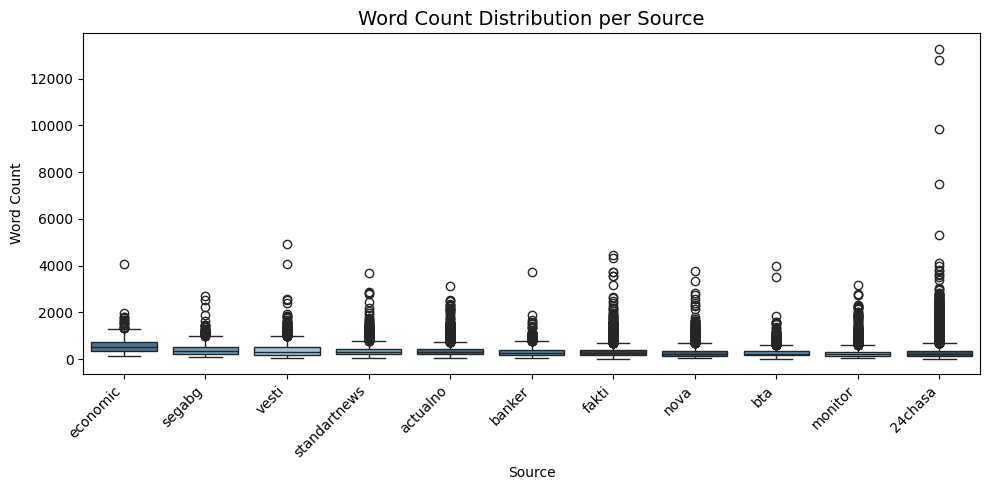

In [2420]:
fig, ax = plt.subplots(figsize=(10, 5))
sources_ordered = (
    df.groupby("source")["word_count"].median().sort_values(ascending=False).index
)
sns.boxplot(
    data=df,
    x="source",
    y="word_count",
    order=sources_ordered,
    palette="Blues_d",
    ax=ax,
    hue="source",
    legend=False,
)
ax.set_title("Word Count Distribution per Source", fontsize=14)
ax.set_xlabel("Source")
ax.set_ylabel("Word Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [2421]:
for source, threshold in [("24chasa", 3000), ("fakti", 2000)]:
    outliers = df[
        (df["source"] == source) & (df["word_count"] > threshold)
    ].sort_values("word_count", ascending=False)
    print(f"=== {source} > {threshold} words: {len(outliers)} ===")
    for _, row in outliers.head(5).iterrows():
        print(f"  [{row['word_count']} words] {row['title']}")
        print(f"  URL: {row['url']}")
        print_by_words(row["full_text"])
        print()

=== 24chasa > 3000 words: 15 ===
  [13275 words] Вижте ситуацията по пътищата на страната в момента
  URL: https://www.24chasa.bg/spravochnik/article/22910525
Ето информация от "Пътна структура" за състоянието на шосетата в страната. I.МЕТЕОРОЛОГИЧНА ОБСТАНОВКА: През първата половина на нощта валежи ще
има главно в планинските райони. До сутринта ще отслабнат и ще спрат. Облачността в повечето места ще се разкъса и
намалее. В източните райони ще е със слаб северозападен вятър. В останалата част от страната вятърът ще стихне и главно
в западната част от Дунавската равнина ще има ниска слоеста облачност и намалена видимост. Утре преди обяд ще бъде предимно
слънчево. Около и след обяд ще се развива купеста облачност, но само на отделни места, главно в планинските райони ще
превали краткотраен дъжд. Вятърът ще е слаб от север-северозапад, в Източна България до умерен от север-североизток. Максималните температури в повечето
места ще бъдат между 22° и 27°, в София – около 24°. ОГРАНИЧЕНИЯ З

There are still outliers for words distribution, but they are valid texts, so all good 

In [2422]:
len(df)

36119

## 7. Media-type suffixes in titles and full_text

Check how many articles carry `(видео)`, `(снимка)`, `(снимки)`, `(снимка+видео)`, `(видео+снимка)` — appended by CMS editors as metadata tags, not actual article content.

In [2424]:
MEDIA_PATTERNS = ["(видео)", "(снимка)", "(снимки)", "(снимка+видео)", "(видео+снимка)", "(видео+снимки)", "(снимки, видео)"]

def media_re(p):
    # Allow optional spaces around + so (снимка+видео) matches (снимка + видео) too
    return re.escape(p).replace(r"\+", r"\s*\+\s*")

combined = "|".join(media_re(p) for p in MEDIA_PATTERNS)

# Per-pattern counts
for field in ["title", "full_text"]:
    print(f"--- {field} ---")
    for p in MEDIA_PATTERNS:
        n = df[field].str.contains(media_re(p), case=False, na=False, regex=True).sum()
        if n:
            print(f"  {p:<22}: {n}")
    total = df[field].str.contains(combined, case=False, na=False, regex=True).sum()
    print(f"  {'TOTAL':<22}: {total}")
    print()

--- title ---
  (видео)               : 1140
  (снимка)              : 87
  (снимки)              : 396
  (видео+снимка)        : 7
  (видео+снимки)        : 65
  (снимки, видео)       : 20
  TOTAL                 : 1715

--- full_text ---
  (видео)               : 1366
  (снимка)              : 73
  (снимки)              : 310
  (снимка+видео)        : 2
  (видео+снимка)        : 8
  (видео+снимки)        : 95
  (снимки, видео)       : 6
  TOTAL                 : 1751



In [2425]:
# Per-source breakdown
for field in ["title", "full_text"]:
    mask = df[field].str.contains(combined, case=False, na=False, regex=True)
    print(f"{field} ({mask.sum()} affected):")
    print(df[mask]["source"].value_counts().to_string())
    print()

title (1715 affected):
source
actualno        811
24chasa         302
nova            246
fakti           193
monitor         122
standartnews     25
vesti            16

full_text (1751 affected):
source
actualno    1335
nova         305
monitor       62
vesti         23
fakti         17
24chasa        9



In [2426]:
def strip_media_suffixes(text: str) -> str:
    if not isinstance(text, str):
        return text
    return re.sub(combined, "", text, flags=re.IGNORECASE).strip()

In [2427]:
df["title"] = df["title"].apply(strip_media_suffixes)
df["full_text"] = df["full_text"].apply(strip_media_suffixes)

In [2428]:
mask = df["title"].str.contains(combined, case=False, na=False, regex=True)
print(f"Remaining titles with media suffixes: {mask.sum()}")

Remaining titles with media suffixes: 0


In [2429]:
mask = df["full_text"].str.contains(combined, case=False, na=False, regex=True)
print(f"Remaining fill_text with media suffixes: {mask.sum()}")

Remaining fill_text with media suffixes: 0


## 8.Updated articles posted in the same time

In [2430]:
def inspect_source_duplicate_similarity(
    df: pd.DataFrame, source: str, threshold: float = 0.5
):
    source_df = df[df["source"] == source].copy()
    groups_found = 0
    high_title_sim = 0
    high_text_sim = 0

    for published_at, group in source_df.groupby("published_at_dt"):
        if len(group) < 2:
            continue

        titles = group["title"].fillna("").tolist()
        texts = group["full_text"].fillna("").tolist()
        urls = group["url"].tolist()
        fetched = group["fetched_at"].tolist()

        try:
            title_sim = cosine_similarity(TfidfVectorizer().fit_transform(titles))[0][1]
            text_sim = cosine_similarity(TfidfVectorizer().fit_transform(texts))[0][1]
        except ValueError:
            continue

        groups_found += 1
        if title_sim >= threshold:
            high_title_sim += 1
        if text_sim >= threshold:
            high_text_sim += 1

        if title_sim < threshold and text_sim < threshold:
            continue

        print(
            f"Published: {published_at} | Title sim: {title_sim:.3f} | Text sim: {text_sim:.3f}"
        )
        for t, u, f in zip(titles, urls, fetched):
            print(f"  [{f}] {t}")
            print(f"    {u}")
        print()

    print(
        f"Source: {source} | Total groups: {groups_found} | Title sim >= {threshold}: {high_title_sim} | Text sim >= {threshold}: {high_text_sim}"
    )

In [2431]:
same_time_all = df.groupby(["source", "published_at_dt"]).filter(lambda x: len(x) > 1)
summary = same_time_all.groupby("source")["published_at_dt"].count()
print("Articles with duplicate timestamps per source:")
print(summary.sort_values(ascending=False))

Articles with duplicate timestamps per source:
source
24chasa         1981
actualno         921
nova             302
vesti            192
bta              188
segabg            10
standartnews       4
fakti              2
Name: published_at_dt, dtype: int64


In [2432]:
inspect_source_duplicate_similarity(df, "fakti", threshold=0.7)

Source: fakti | Total groups: 1 | Title sim >= 0.7: 0 | Text sim >= 0.7: 0


In [2433]:
inspect_source_duplicate_similarity(df, "segabg", threshold=0.7)

Published: 2026-05-13 12:56:46+00:00 | Title sim: 0.921 | Text sim: 0.934
  [2026-05-13T18:05:41.313705+00:00] България изненадващо бе само с посланик на натовска среща на върха
    https://www.segabg.com/hot/category-foreign-country/bulgariya-iznenadvashto-be-samo-poslanik-na-natovska-sreshta-na-vurha
  [2026-05-13T14:41:35.131317+00:00] България е изненадващо само с посланик на натовска среща на върха
    https://www.segabg.com/hot/category-foreign-country/bulgariya-e-iznenadvashto-samo-poslanik-na-natovska-sreshta-na-vurha

Published: 2026-05-19 10:24:00+00:00 | Title sim: 0.000 | Text sim: 0.949
  [2026-05-19T15:31:28.325685+00:00] ПП и ДБ излязоха със свои промени в правилника на парламента
    https://www.segabg.com/category-bulgaria/pp-i-db-izlyazoha-svoi-promeni-pravilnika-na-parlamenta
  [2026-05-19T11:23:17.069067+00:00] От "Демократична България" поискаха повече дебати и по-малко бюрокрация в НС
    https://www.segabg.com/category-bulgaria/demokratichna-bulgariya-poiskaha-po

In [2434]:
inspect_source_duplicate_similarity(df, "bta", threshold=0.7)

Published: 2026-05-05 15:05:00+00:00 | Title sim: 1.000 | Text sim: 0.883
  [2026-05-05T16:13:48.135656+00:00] Президентът Илияна Йотова ще връчи мандата за съставяне на правителство на 7 май
    https://www.bta.bg/bg/news/bulgaria/1120064-prezidentat-iliyana-yotova-shte-vrachi-mandata-za-sastavyane-na-pravitelstvo-na-
  [2026-05-05T15:32:43.295435+00:00] Президентът Илияна Йотова ще връчи мандата за съставяне на правителство на 7 май
    https://www.bta.bg/bg/news/bulgaria/1120042-prezidentat-iliyana-yotova-shte-vrachi-mandata-za-sastavyane-na-pravitelstvo-na-

Published: 2026-05-07 14:10:00+00:00 | Title sim: 1.000 | Text sim: 0.667
  [2026-05-07T14:18:48.663588+00:00] Кандидатът за премиер от "Прогресивна България" Румен Радев представи структура и състав на проектокабинет
    https://www.bta.bg/bg/news/bulgaria/1120749-kandidatat-za-premier-ot-progresivna-balgariya-rumen-radev-predstavi-struktura
  [2026-05-07T14:18:48.663519+00:00] Кандидатът за премиер от "Прогресивна България" Р

In [2435]:
inspect_source_duplicate_similarity(df, "vesti", threshold=0.7)

Published: 2026-05-05 03:45:00+00:00 | Title sim: 0.063 | Text sim: 0.833
  [2026-05-05T10:07:47.065231+00:00] "Прогресивна България": До края на седмицата ще има правителство
    https://www.vesti.bg/bulgaria/progresivna-bylgariiado-kraia-na-sedmicata-shte-ima-pravitelstvo-6258729
  [2026-05-05T06:20:11.295865+00:00] Старт на консултациите: Президентът се среща с парламентарните групи
    https://www.vesti.bg/bulgaria/start-na-konsultaciite-prezidentytse-sreshta-s-parlamentarnite-grupi-6258729

Published: 2026-05-05 09:10:00+00:00 | Title sim: 0.580 | Text sim: 0.911
  [2026-05-05T15:33:44.268320+00:00] Две земетресения разлюляха Сърбия, едното е причинило сериозни щети
    https://www.vesti.bg/sviat/dve-zemetreseniia-razliuliaha-syrbiia-ednoto-e-prichinilo-seriozni-shteti-6258762
  [2026-05-05T10:07:47.064850+00:00] Две земетресения разлюляха Сърбия
    https://www.vesti.bg/sviat/dve-zemetreseniia-razliuliaha-syrbiia-6258762

Published: 2026-05-07 05:41:00+00:00 | Title sim: 0.226 | 

In [2436]:
inspect_source_duplicate_similarity(df, "nova", threshold=0.7)

Published: 2026-04-23 06:50:22+00:00 | Title sim: 0.747 | Text sim: 0.694
  [2026-04-23T17:25:37.181158+00:00] Челен сблъсък между влакове в Дания
    https://nova.bg/news/view/2026/04/23/534823/%D1%87%D0%B5%D0%BB%D0%B5%D0%BD-%D1%81%D0%B1%D0%BB%D1%8A%D1%81%D1%8A%D0%BA-%D0%BC%D0%B5%D0%B6%D0%B4%D1%83-%D0%B2%D0%BB%D0%B0%D0%BA%D0%BE%D0%B2%D0%B5-%D0%B2-%D0%B4%D0%B0%D0%BD%D0%B8%D1%8F-%D0%B2%D0%B8%D0%B4%D0%B5%D0%BE%D1%81%D0%BD%D0%B8%D0%BC%D0%BA%D0%B8/
  [2026-04-23T09:47:56.601838+00:00] Челен сблъсък между влакове в Дания, има пострадали
    https://nova.bg/news/view/2026/04/23/534823/%D1%87%D0%B5%D0%BB%D0%B5%D0%BD-%D1%81%D0%B1%D0%BB%D1%8A%D1%81%D1%8A%D0%BA-%D0%BC%D0%B5%D0%B6%D0%B4%D1%83-%D0%B2%D0%BB%D0%B0%D0%BA%D0%BE%D0%B2%D0%B5-%D0%B2-%D0%B4%D0%B0%D0%BD%D0%B8%D1%8F-%D0%B8%D0%BC%D0%B0-%D0%BF%D0%BE%D1%81%D1%82%D1%80%D0%B0%D0%B4%D0%B0%D0%BB%D0%B8-%D0%B2%D0%B8%D0%B4%D0%B5%D0%BE%D1%81%D0%BD%D0%B8%D0%BC%D0%BA%D0%B8/

Published: 2026-04-23 07:53:00+00:00 | Title sim: 0.896 | Text sim: 0.648
  [20

In [2437]:
inspect_source_duplicate_similarity(df, "actualno", threshold=0.7)

Published: 2026-04-21 11:11:00+00:00 | Title sim: 0.317 | Text sim: 0.825
  [2026-04-21T13:49:43.207655+00:00] Крум Зарков поиска вот на доверие и обяви мащабен процес на промяна в БСП
    https://www.actualno.com/politics/krum-zarkov-poiska-vot-na-doverie-i-objavi-mashtaben-proces-na-promjana-v-bsp-news_2584392.html
  [2026-04-21T11:12:12.529337+00:00] Оставката чака зад ъгъла: Крум Зарков иска вот на доверие от БСП след "много лошия" резултат
    https://www.actualno.com/politics/ostavkata-chaka-zad-ygyla-krum-zarkov-iska-vot-na-doverie-ot-bsp-sled-mnogo-loshija-rezultat-news_2584392.html

Published: 2026-04-29 15:01:00+00:00 | Title sim: 0.802 | Text sim: 0.896
  [2026-04-29T19:42:08.606269+00:00] Стерьовски пак се активира: Хвана го антибългарска параноя в съда
    https://www.actualno.com/balkani/steriovski-pak-se-aktivira-hvana-go-antibylgarska-paranoja-v-syda-news_2588104.html
  [2026-04-29T17:42:13.472936+00:00] Щерьовски пак се активира: Хвана го антибългарска параноя в съда
 

In [2438]:
inspect_source_duplicate_similarity(df, "24chasa", threshold=0.7)

Published: 2026-04-22 16:49:00+00:00 | Title sim: 1.000 | Text sim: 0.993
  [2026-04-22T20:58:34.871000+00:00] Испански прокурор поиска делото за корупция срещу съпругата на премиера да бъде прекратено
    https://www.24chasa.bg/mezhdunarodni/article/22716371
  [2026-04-22T17:05:17.998300+00:00] Испански прокурор поиска делото за корупция срещу съпругата на премиера да бъде прекратено
    https://www.24chasa.bg/zdrave/article/22716371

Published: 2026-04-29 11:43:00+00:00 | Title sim: 0.000 | Text sim: 0.721
  [2026-04-29T14:03:37.351316+00:00] Вижте какво реши служебното правителство днес
    https://www.24chasa.bg/bulgaria/article/22755990
  [2026-04-29T14:03:37.351307+00:00] Ердоган обяви, че е преодолян критичният праг по разоръжаването на ПКК
    https://www.24chasa.bg/mezhdunarodni/article/22755998

Published: 2026-05-20 11:55:00+00:00 | Title sim: 0.000 | Text sim: 0.813
  [2026-05-20T15:27:29.025491+00:00] Прибират цялата печалба на държавните дружества от 2025 г.
    https://w

In [2439]:
def drop_updated_duplicates(
    df: pd.DataFrame, sources: list[str], threshold: float = 0.7
) -> pd.DataFrame:
    df = df.sort_values("fetched_at", ascending=False).reset_index(drop=True)
    rows_to_drop = set()

    for source in sources:
        source_df = df[df["source"] == source]
        source_dropped = 0

        for published_at, group in source_df.groupby("published_at_dt"):
            if len(group) < 2:
                continue

            titles = group["title"].fillna("").tolist()
            texts = group["full_text"].fillna("").tolist()

            try:
                title_sim = cosine_similarity(TfidfVectorizer().fit_transform(titles))[
                    0
                ][1]
                text_sim = cosine_similarity(TfidfVectorizer().fit_transform(texts))[0][
                    1
                ]
            except ValueError:
                continue

            if title_sim < threshold and text_sim < threshold:
                continue

            indices = group.index.tolist()
            to_drop = indices[1:]
            rows_to_drop.update(to_drop)
            source_dropped += len(to_drop)

        print(f"Source: {source} | Dropping: {source_dropped}")

    before = len(df)
    df = df.drop(index=rows_to_drop).reset_index(drop=True)
    print(f"\nTotal dropped: {before - len(df)} | Remaining: {len(df)}")
    return df

In [2440]:
sources_to_clean = ["segabg", "bta", "vesti", "nova", "actualno"]
df = drop_updated_duplicates(df, sources_to_clean)

Source: segabg | Dropping: 5
Source: bta | Dropping: 15
Source: vesti | Dropping: 14
Source: nova | Dropping: 135
Source: actualno | Dropping: 5

Total dropped: 174 | Remaining: 35945


Update the parquet file

In [2442]:
out_path = "../data/processed/articles_clean_notebook.parquet"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df.to_parquet(out_path, index=False)
print(f"Saved {len(df)} articles → {out_path}")

Saved 35945 articles → ../data/processed/articles_clean_notebook.parquet


# 9. Comparation with raw data

In [2449]:
DATA_DIR = "../data/raw"

records = []
for date_folder in sorted(os.listdir(DATA_DIR)):
    folder_path = os.path.join(DATA_DIR, date_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        if filename.endswith(".json"):
            filepath = os.path.join(folder_path, filename)
            with open(filepath, encoding="utf-8") as f:
                records.append(json.load(f))

df_raw = pd.DataFrame(records)
df_raw["published_at_dt"] = pd.to_datetime(
    df["published_at"], format="ISO8601", utc=True
)
print(f"Total articles loaded: {len(df_raw)}")

Total articles loaded: 45932


In [2459]:
comp = (
    pd.DataFrame(
        {"raw": df_raw["source"].value_counts(), "cleaned": df["source"].value_counts()}
    )
    .fillna(0)
    .astype(int)
)
comp["dropped"] = comp["raw"] - comp["cleaned"]
comp["dropped %"] = (comp["dropped"] / comp["raw"] * 100).round(1).astype(str) + "%"

total = comp[["raw", "cleaned", "dropped"]].sum()
total["dropped %"] = str(round(total["dropped"] / total["raw"] * 100, 1)) + "%"
total.name = "TOTAL"
comp = pd.concat([comp, total.to_frame().T])
comp

,raw,cleaned,dropped,dropped %
24chasa,9978,9734,244,2.4%
actualno,5902,5602,300,5.1%
banker,705,705,0,0.0%
blitz,531,0,531,100.0%
bta,3179,3115,64,2.0%
capital,30,0,30,100.0%
dnevnik,256,0,256,100.0%
economic,308,308,0,0.0%
fakti,5915,5846,69,1.2%
monitor,9450,2199,7251,76.7%
